In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.applications import Xception
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import numpy as np
from keras.losses import BinaryFocalCrossentropy
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.4,
    height_shift_range=0.4,
    shear_range=0.4,
    zoom_range=0.4,
    brightness_range=[0.7, 1.3],
    horizontal_flip=True,
    fill_mode='nearest'
)

validation_datagen = ImageDataGenerator(rescale=1./255)

train_dir = '/content/drive/MyDrive/train'
validation_dir = '/content/drive/MyDrive/validation'

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=True
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

base_model = Xception(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

for layer in base_model.layers:
    layer.trainable = False

feature_extractor = models.Model(inputs=base_model.input, outputs=base_model.output)

num_train_samples = train_generator.samples

X_train_features = []
y_train_labels = []

for i, (images, labels) in enumerate(train_generator):
    features = feature_extractor.predict(images, verbose=0)
    X_train_features.append(features)
    y_train_labels.append(labels)
    if i >= len(train_generator) - 1:
        break

X_train_features = np.vstack(X_train_features)
y_train_labels = np.hstack(y_train_labels)
print(f"شکل ویژگی‌های استخراج شده آموزش: {X_train_features.shape}")
print(f"شکل برچسب‌های آموزش: {y_train_labels.shape}")


print("در حال اعمال SMOTE برای بالانس کردن داده‌ها...")
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_features.reshape(X_train_features.shape[0], -1),
    y_train_labels
)

X_train_resampled = X_train_resampled.reshape(-1, 7, 7, 2048)
print(f"شکل ویژگی‌های پس از SMOTE: {X_train_resampled.shape}")
print(f"شکل برچسب‌های پس از SMOTE: {y_train_resampled.shape}")

X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(
    X_train_resampled, y_train_resampled, test_size=0.2, random_state=42, stratify=y_train_resampled
)
print(f"شکل نهایی داده‌های آموزش (پس از تقسیم): {X_train_final.shape}")
print(f"شکل نهایی داده‌های اعتبارسنجی (پس از تقسیم): {X_val_final.shape}")

model = models.Sequential([
    layers.Input(shape=(7, 7, 2048)),
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4),
    layers.Dense(512, kernel_regularizer=l2(0.0005)),
    layers.BatchNormalization(),
    layers.LeakyReLU(negative_slope=0.1),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

loss_fn = BinaryFocalCrossentropy(alpha=0.25, gamma=2.0)
model.compile(optimizer=AdamW(learning_rate=3e-5), loss=loss_fn, metrics=['accuracy'])

class_weights_smote = compute_class_weight(class_weight="balanced", classes=np.unique(y_train_final), y=y_train_final)
class_weights_dict_smote = {i: class_weights_smote[i] for i in range(len(class_weights_smote))}

early_stopping = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-7, verbose=1)
checkpoint = ModelCheckpoint("optimized_xception.keras", monitor='val_accuracy', save_best_only=True, verbose=1)

history = model.fit(
    X_train_final,
    y_train_final,
    validation_data=(X_val_final, y_val_final),
    epochs=100,
    callbacks=[early_stopping, reduce_lr, checkpoint],
    class_weight=class_weights_dict_smote,
    batch_size=32
)

print("\n--- ارزیابی نهایی مدل ---")
val_loss, val_acc = model.evaluate(X_val_final, y_val_final, verbose=0)
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Validation Loss: {val_loss:.4f}")

y_pred = model.predict(X_val_final, verbose=0)
y_pred_classes = (y_pred > 0.5).astype("int32").flatten()

print("\nClassification Report:\n", classification_report(y_val_final, y_pred_classes))

model.save("optimized_xception.keras")

Found 1246 images belonging to 2 classes.
Found 309 images belonging to 2 classes.
شکل ویژگی‌های استخراج شده آموزش: (1246, 7, 7, 2048)
شکل برچسب‌های آموزش: (1246,)
در حال اعمال SMOTE برای بالانس کردن داده‌ها...
شکل ویژگی‌های پس از SMOTE: (1486, 7, 7, 2048)
شکل برچسب‌های پس از SMOTE: (1486,)
شکل نهایی داده‌های آموزش (پس از تقسیم): (1188, 7, 7, 2048)
شکل نهایی داده‌های اعتبارسنجی (پس از تقسیم): (298, 7, 7, 2048)
Epoch 1/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5093 - loss: 0.8530
Epoch 1: val_accuracy improved from -inf to 0.61074, saving model to optimized_xception.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - accuracy: 0.5102 - loss: 0.8520 - val_accuracy: 0.6107 - val_loss: 0.5790 - learning_rate: 3.0000e-05
Epoch 2/100
32/38 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6258 - loss: 0.7171
Epoch 2: val_accuracy improved from 0.61074 to 0.74497, saving model to optimized_xception.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.6262 - loss: 0.7154 - val

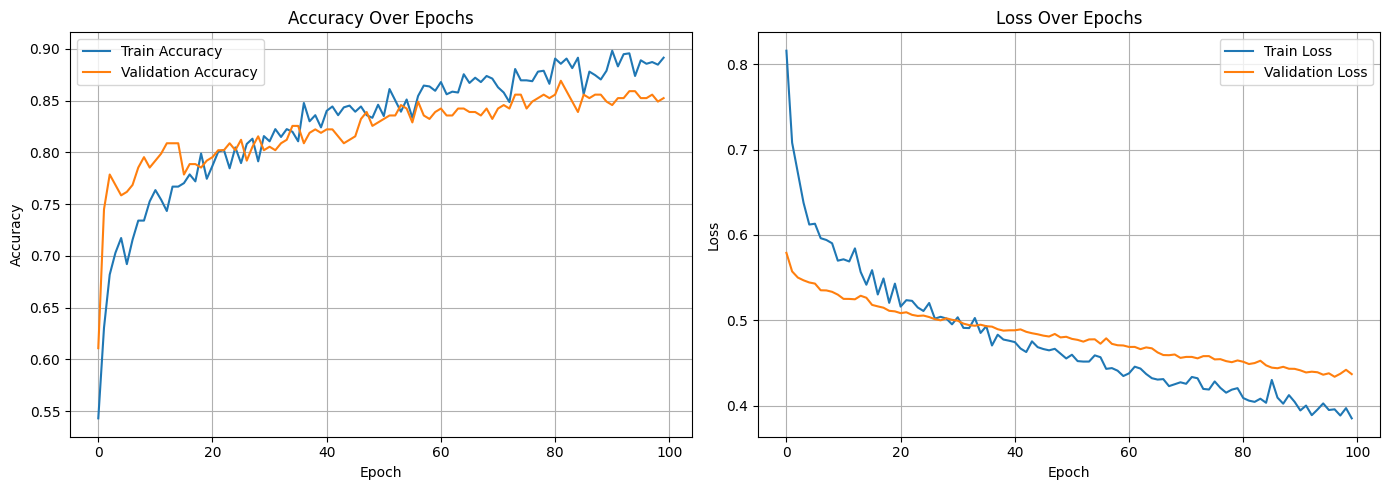

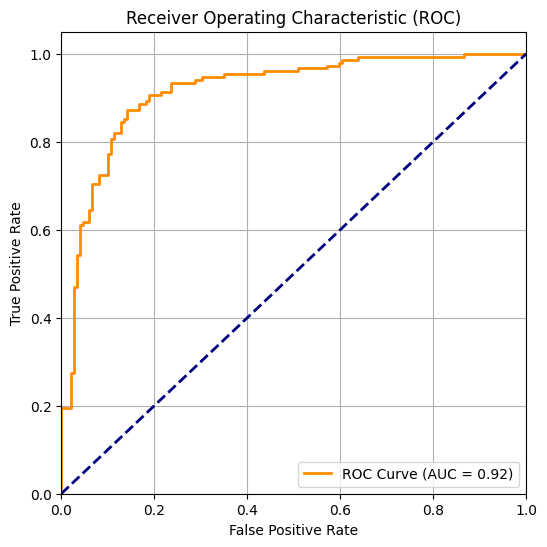

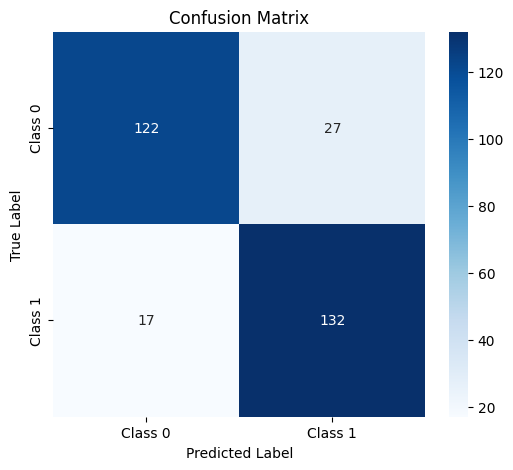

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc
import seaborn as sns
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(y_val_final, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

cm = confusion_matrix(y_val_final, y_pred_classes)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.applications import Xception
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import numpy as np
from keras.losses import BinaryFocalCrossentropy
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.4,
    height_shift_range=0.4,
    shear_range=0.4,
    zoom_range=0.4,
    brightness_range=[0.7, 1.3],
    horizontal_flip=True,
    fill_mode='nearest'
)

validation_datagen = ImageDataGenerator(rescale=1./255)

train_dir = '/content/drive/MyDrive/train'
validation_dir = '/content/drive/MyDrive/validation'

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=True
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

base_model = Xception(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

for layer in base_model.layers:
    layer.trainable = False

feature_extractor = models.Model(inputs=base_model.input, outputs=base_model.output)

num_train_samples = train_generator.samples

X_train_features = []
y_train_labels = []

for i, (images, labels) in enumerate(train_generator):
    features = feature_extractor.predict(images, verbose=0)
    X_train_features.append(features)
    y_train_labels.append(labels)

    if i >= len(train_generator) - 1:
        break

X_train_features = np.vstack(X_train_features)
y_train_labels = np.hstack(y_train_labels)

smote = SMOTE(sampling_strategy='auto', random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_features.reshape(X_train_features.shape[0], -1),
    y_train_labels
)


X_train_resampled = X_train_resampled.reshape(-1, 7, 7, 2048)

X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(
    X_train_resampled, y_train_resampled, test_size=0.2, random_state=42, stratify=y_train_resampled
)

model = models.Sequential([
    layers.Input(shape=(7, 7, 2048)),
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4),
    layers.Dense(512, kernel_regularizer=l2(0.0005)),
    layers.BatchNormalization(),
    layers.LeakyReLU(negative_slope=0.1),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

loss_fn = BinaryFocalCrossentropy(alpha=0.25, gamma=2.0)

model.compile(optimizer=AdamW(learning_rate=3e-5), loss=loss_fn, metrics=['accuracy'])

class_weights_smote = compute_class_weight(class_weight="balanced", classes=np.unique(y_train_final), y=y_train_final)
class_weights_dict_smote = {i: class_weights_smote[i] for i in range(len(class_weights_smote))}

early_stopping = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-7, verbose=1)
checkpoint = ModelCheckpoint("optimized_xception2.keras", monitor='val_accuracy', save_best_only=True, verbose=1)

history = model.fit(
    X_train_final,
    y_train_final,
    validation_data=(X_val_final, y_val_final),
    epochs=150,
    callbacks=[early_stopping, reduce_lr, checkpoint],
    class_weight=class_weights_dict_smote,
    batch_size=32
)

val_loss, val_acc = model.evaluate(X_val_final, y_val_final, verbose=0)
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Validation Loss: {val_loss:.4f}")

y_pred = model.predict(X_val_final, verbose=0)
y_pred_classes = (y_pred > 0.5).astype("int32").flatten()

print("\nClassification Report:\n", classification_report(y_val_final, y_pred_classes))

model.save("optimized_xception2.keras")

Found 1246 images belonging to 2 classes.
Found 309 images belonging to 2 classes.
Epoch 1/150
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.5379 - loss: 0.6980
Epoch 1: val_accuracy improved from -inf to 0.73826, saving model to optimized_xception2.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - accuracy: 0.5390 - loss: 0.6971 - val_accuracy: 0.7383 - val_loss: 0.5516 - learning_rate: 3.0000e-05
Epoch 2/150
34/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6539 - loss: 0.6441
Epoch 2: val_accuracy improved from 0.73826 to 0.79530, saving model to optimized_xception2.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6565 - loss: 0.6423 - val_accuracy: 0.7953 - val_loss: 0.5323 - learning_rate: 3.0000e-05
Epoch 3/150
34/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6884 - loss: 0.6213
Epoch 3: val_accuracy improved from 0.79530 to 0.82886, saving model to optimized_xception2.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6890 - loss: 0.6211 - val_ac

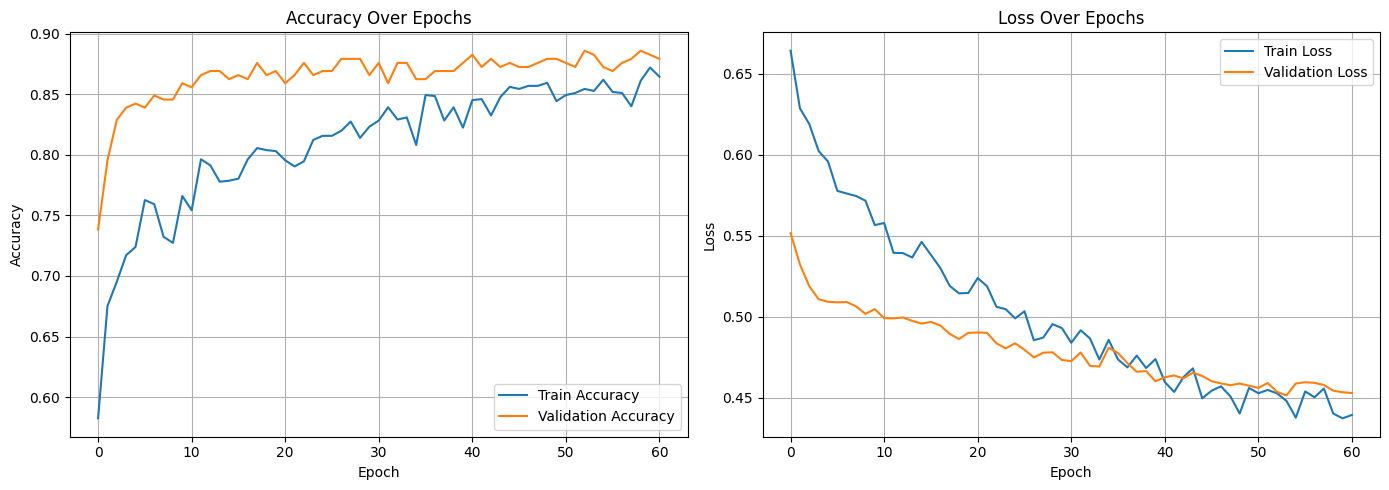

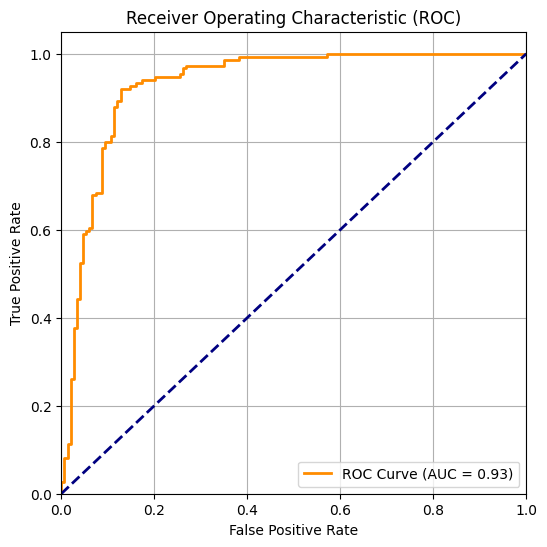

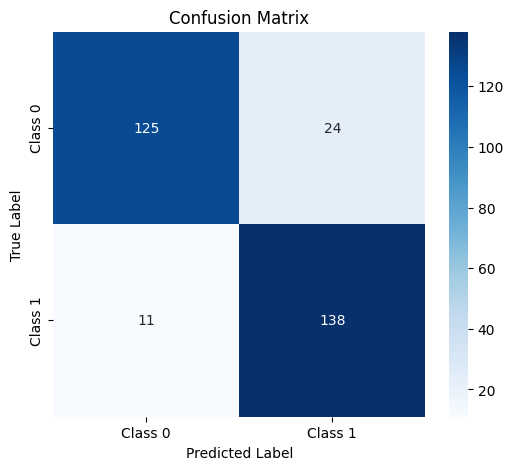

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc
import seaborn as sns

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(y_val_final, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

cm = confusion_matrix(y_val_final, y_pred_classes)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.applications import Xception
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import numpy as np
from keras.losses import BinaryFocalCrossentropy
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.4,
    height_shift_range=0.4,
    shear_range=0.4,
    zoom_range=0.4,
    brightness_range=[0.7, 1.3],
    horizontal_flip=True,
    fill_mode='nearest'
)

validation_datagen = ImageDataGenerator(rescale=1./255)

train_dir = '/content/drive/MyDrive/train'
validation_dir = '/content/drive/MyDrive/validation'

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=True
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

base_model = Xception(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

for layer in base_model.layers:
    layer.trainable = False


feature_extractor = models.Model(inputs=base_model.input, outputs=base_model.output)
num_train_samples = train_generator.samples

X_train_features = []
y_train_labels = []

for i, (images, labels) in enumerate(train_generator):
    features = feature_extractor.predict(images, verbose=0)
    X_train_features.append(features)
    y_train_labels.append(labels)

    if i >= len(train_generator) - 1:
        break

X_train_features = np.vstack(X_train_features)
y_train_labels = np.hstack(y_train_labels)

smote = SMOTE(sampling_strategy='auto', random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_features.reshape(X_train_features.shape[0], -1),
    y_train_labels
)

X_train_resampled = X_train_resampled.reshape(-1, 7, 7, 2048)

X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(
    X_train_resampled, y_train_resampled, test_size=0.2, random_state=42, stratify=y_train_resampled
)


model = models.Sequential([
    layers.Input(shape=(7, 7, 2048)),
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4),
    layers.Dense(512, kernel_regularizer=l2(0.0005)),
    layers.BatchNormalization(),
    layers.LeakyReLU(negative_slope=0.1),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

loss_fn = BinaryFocalCrossentropy(alpha=0.25, gamma=2.0)

model.compile(optimizer=AdamW(learning_rate=3e-5), loss=loss_fn, metrics=['accuracy'])

class_weights_smote = compute_class_weight(class_weight="balanced", classes=np.unique(y_train_final), y=y_train_final)
class_weights_dict_smote = {i: class_weights_smote[i] for i in range(len(class_weights_smote))}

early_stopping = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-7, verbose=1)
checkpoint = ModelCheckpoint("optimized_xception3.keras", monitor='val_accuracy', save_best_only=True, verbose=1)

history = model.fit(
    X_train_final,
    y_train_final,
    validation_data=(X_val_final, y_val_final),
    epochs=150,
    callbacks=[early_stopping, reduce_lr, checkpoint],
    class_weight=class_weights_dict_smote,
    batch_size=32
)

val_loss, val_acc = model.evaluate(X_val_final, y_val_final, verbose=0)
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Validation Loss: {val_loss:.4f}")

y_pred = model.predict(X_val_final, verbose=0)
y_pred_classes = (y_pred > 0.5).astype("int32").flatten()

print("\nClassification Report:\n", classification_report(y_val_final, y_pred_classes))

model.save("optimized_xception3.keras")

Found 1246 images belonging to 2 classes.
Found 309 images belonging to 2 classes.
Epoch 1/150
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.5649 - loss: 0.8662
Epoch 1: val_accuracy improved from -inf to 0.72483, saving model to optimized_xception3.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 95ms/step - accuracy: 0.5650 - loss: 0.8657 - val_accuracy: 0.7248 - val_loss: 0.5516 - learning_rate: 3.0000e-05
Epoch 2/150
32/38 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6173 - loss: 0.7235
Epoch 2: val_accuracy improved from 0.72483 to 0.78188, saving model to optimized_xception3.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6201 - loss: 0.7208 - val_accuracy: 0.7819 - val_loss: 0.5371 - learning_rate: 3.0000e-05
Epoch 3/150
32/38 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6912 - loss: 0.6609
Epoch 3: val_accuracy improved from 0.78188 to 0.81544, saving model to optimized_xception3.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6897 - loss: 0.6639 - val_ac

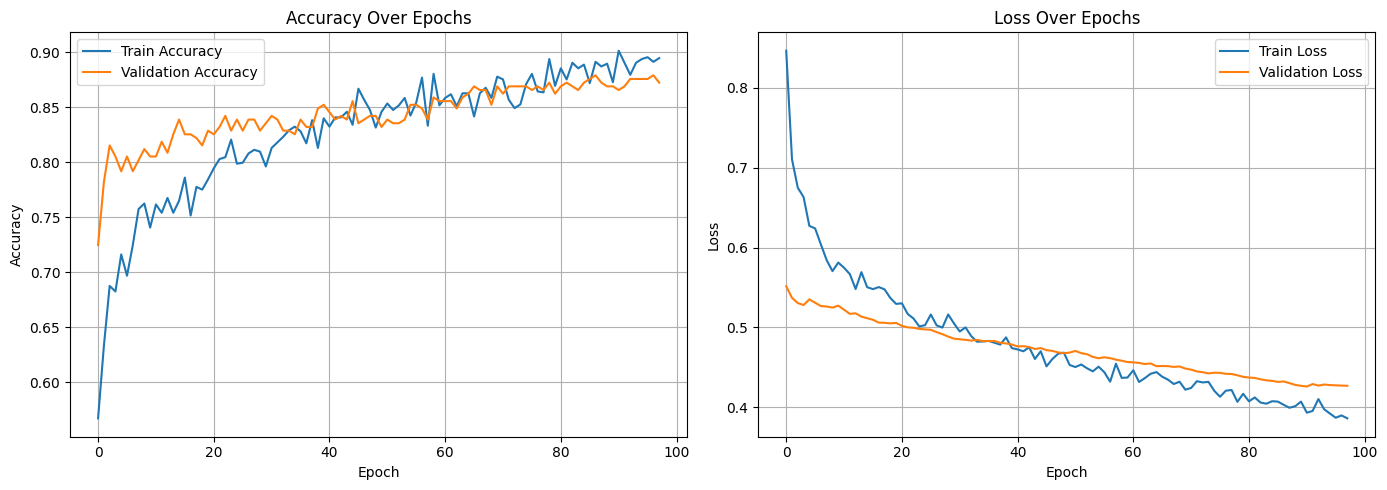

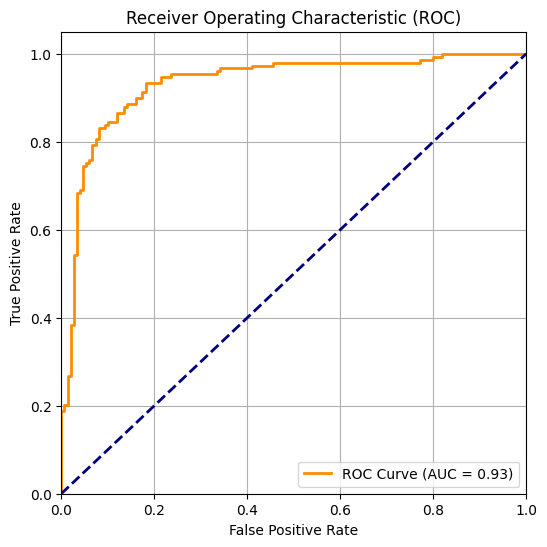

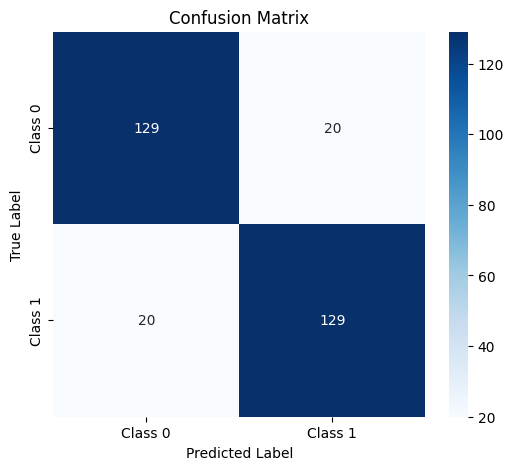

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc
import seaborn as sns

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(y_val_final, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

cm = confusion_matrix(y_val_final, y_pred_classes)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.applications import Xception
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import numpy as np
from keras.losses import BinaryFocalCrossentropy
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.4,
    height_shift_range=0.4,
    shear_range=0.4,
    zoom_range=0.4,
    brightness_range=[0.7, 1.3],
    horizontal_flip=True,
    fill_mode='nearest'
)

validation_datagen = ImageDataGenerator(rescale=1./255)

train_dir = '/content/drive/MyDrive/train'
validation_dir = '/content/drive/MyDrive/validation'

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=True
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

base_model = Xception(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

for layer in base_model.layers:
    layer.trainable = False


feature_extractor = models.Model(inputs=base_model.input, outputs=base_model.output)
num_train_samples = train_generator.samples

X_train_features = []
y_train_labels = []

for i, (images, labels) in enumerate(train_generator):
    features = feature_extractor.predict(images, verbose=0)
    X_train_features.append(features)
    y_train_labels.append(labels)

    if i >= len(train_generator) - 1:
        break

X_train_features = np.vstack(X_train_features)
y_train_labels = np.hstack(y_train_labels)

smote = SMOTE(sampling_strategy='auto', random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_features.reshape(X_train_features.shape[0], -1),
    y_train_labels
)

X_train_resampled = X_train_resampled.reshape(-1, 7, 7, 2048)

X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(
    X_train_resampled, y_train_resampled, test_size=0.2, random_state=42, stratify=y_train_resampled
)


model = models.Sequential([
    layers.Input(shape=(7, 7, 2048)),
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4),
    layers.Dense(512, kernel_regularizer=l2(0.0005)),
    layers.BatchNormalization(),
    layers.LeakyReLU(negative_slope=0.1),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

loss_fn = BinaryFocalCrossentropy(alpha=0.25, gamma=2.0)

model.compile(optimizer=AdamW(learning_rate=3e-5), loss=loss_fn, metrics=['accuracy'])

class_weights_smote = compute_class_weight(class_weight="balanced", classes=np.unique(y_train_final), y=y_train_final)
class_weights_dict_smote = {i: class_weights_smote[i] for i in range(len(class_weights_smote))}

early_stopping = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-7, verbose=1)
checkpoint = ModelCheckpoint("optimized_xception4.keras", monitor='val_accuracy', save_best_only=True, verbose=1)

history = model.fit(
    X_train_final,
    y_train_final,
    validation_data=(X_val_final, y_val_final),
    epochs=150,
    callbacks=[early_stopping, reduce_lr, checkpoint],
    class_weight=class_weights_dict_smote,
    batch_size=32
)

val_loss, val_acc = model.evaluate(X_val_final, y_val_final, verbose=0)
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Validation Loss: {val_loss:.4f}")

y_pred = model.predict(X_val_final, verbose=0)
y_pred_classes = (y_pred > 0.5).astype("int32").flatten()

print("\nClassification Report:\n", classification_report(y_val_final, y_pred_classes))

model.save("optimized_xception4.keras")

Found 1246 images belonging to 2 classes.
Found 309 images belonging to 2 classes.
Epoch 1/150
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5325 - loss: 0.8610
Epoch 1: val_accuracy improved from -inf to 0.68456, saving model to optimized_xception4.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step - accuracy: 0.5327 - loss: 0.8613 - val_accuracy: 0.6846 - val_loss: 0.5714 - learning_rate: 3.0000e-05
Epoch 2/150
32/38 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6490 - loss: 0.7329
Epoch 2: val_accuracy improved from 0.68456 to 0.72483, saving model to optimized_xception4.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6492 - loss: 0.7298 - val_accuracy: 0.7248 - val_loss: 0.5552 - learning_rate: 3.0000e-05
Epoch 3/150
34/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7033 - loss: 0.6809
Epoch 3: val_accuracy improved from 0.72483 to 0.76846, saving model to optimized_xception4.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7014 - loss: 0.6806 - val_ac

In [ ]:
####### پاتولوژی######

In [ ]:
import pandas as pd
from PIL import Image
import os
from google.colab import files
uploaded = files.upload()

Saving train - Copy.xlsx to train - Copy.xlsx
Saving validation - Copy.xlsx to validation - Copy.xlsx


In [ ]:
import os
import pandas as pd

train_image_dir = "/content/drive/MyDrive/train"
val_image_dir = "/content/drive/MyDrive/validation"

image_counts = {
    "train_malignant": 0,
    "train_benign": 0,
    "validation_malignant": 0,
    "validation_benign": 0
}

def get_correct_image_name(image_name):
    return image_name.strip().lower().replace(".jpg", "")

def check_and_count_images(image_name, dataset_type):
    image_name_corrected = get_correct_image_name(image_name)

    if dataset_type == "train":
        if os.path.exists(os.path.join(train_image_dir, "malignant", f"{image_name_corrected}.jpg")):
            image_counts["train_malignant"] += 1
            print(f"{image_name_corrected}.jpg belongs to train (malignant)")
        if os.path.exists(os.path.join(train_image_dir, "benign", f"{image_name_corrected}.jpg")):
            image_counts["train_benign"] += 1
            print(f"{image_name_corrected}.jpg belongs to train (benign)")

    elif dataset_type == "validation":
        if os.path.exists(os.path.join(val_image_dir, "malignant", f"{image_name_corrected}.jpg")):
            image_counts["validation_malignant"] += 1
            print(f"{image_name_corrected}.jpg belongs to validation (malignant)")
        if os.path.exists(os.path.join(val_image_dir, "benign", f"{image_name_corrected}.jpg")):
            image_counts["validation_benign"] += 1
            print(f"{image_name_corrected}.jpg belongs to validation (benign)")

train_df = pd.read_excel("train - Copy.xlsx")
val_df = pd.read_excel("validation - Copy.xlsx")

train_df["dermoscopy_image_path"] = train_df["dermoscopy_image_path"].apply(lambda x: f"{x.strip().lower()}.jpg")
val_df["dermoscopy_image_path"] = val_df["dermoscopy_image_path"].apply(lambda x: f"{x.strip().lower()}.jpg")

for image_name in train_df["dermoscopy_image_path"]:
    check_and_count_images(image_name, "train")
for image_name in val_df["dermoscopy_image_path"]:
    check_and_count_images(image_name, "validation")


total_images = sum(image_counts.values())
print("\nFinal Results:")
print(f"Total number of images: {total_images}")
print(f"تعداد تصاویر در فولدر train (malignant): {image_counts['train_malignant']}")
print(f"تعداد تصاویر در فولدر train (benign): {image_counts['train_benign']}")
print(f"تعداد تصاویر در فولدر validation (malignant): {image_counts['validation_malignant']}")
print(f"تعداد تصاویر در فولدر validation (benign): {image_counts['validation_benign']}")

p114.jpg belongs to train (malignant)
p114-1.jpg belongs to train (malignant)
p115.jpg belongs to train (malignant)
p115-1.jpg belongs to train (malignant)
p115-2.jpg belongs to train (malignant)
p112.jpg belongs to train (malignant)
p112-1.jpg belongs to train (malignant)
p112-2.jpg belongs to train (malignant)
p112-3.jpg belongs to train (malignant)
p112-4.jpg belongs to train (malignant)
p112-5.jpg belongs to train (malignant)
p20-1.jpg belongs to train (benign)
p20-2.jpg belongs to train (benign)
p111.jpg belongs to train (malignant)
p111-1.jpg belongs to train (malignant)
p111-3.jpg belongs to train (malignant)
p111-4.jpg belongs to train (malignant)
p111-5.jpg belongs to train (malignant)
p111-6.jpg belongs to train (malignant)
p111-7.jpg belongs to train (malignant)
p111-8.jpg belongs to train (malignant)
p107-1.jpg belongs to train (malignant)
p107-2.jpg belongs to train (malignant)
p107-3.jpg belongs to train (malignant)
p22-3.jpg belongs to train (malignant)
p22-7.jpg belongs

In [ ]:
import pandas as pd
import os

train_df = pd.read_excel('/content/train - Copy.xlsx')
validation_df = pd.read_excel('/content/validation - Copy.xlsx')

print("Train DataFrame:")
print(train_df.head())

print("\nValidation DataFrame:")
print(validation_df.head())

train_images_path = '/content/drive/MyDrive/train'
validation_images_path = '/content/drive/MyDrive/validation'

def get_image_path(row, base_path):
    diagnosis_folder = 'benign' if row['diagnosis'] == 0 else 'malignant'
    return os.path.join(base_path, diagnosis_folder, f"{row['dermoscopy_image_path']}.jpg")

train_df['image_path'] = train_df.apply(lambda row: get_image_path(row, train_images_path), axis=1)

validation_df['image_path'] = validation_df.apply(lambda row: get_image_path(row, validation_images_path), axis=1)

print("\nUpdated Train DataFrame with image paths:")
print(train_df[['dermoscopy_image_path', 'image_path']].head())

print("\nUpdated Validation DataFrame with image paths:")
print(validation_df[['dermoscopy_image_path', 'image_path']].head())

train_df.to_excel('/content/train_with_image_paths.xlsx', index=False)
validation_df.to_excel('/content/validation_with_image_paths.xlsx', index=False)

Train DataFrame:
  gender                                clinical_impression  \
0      f  Dysplastic nevus-Lentigo/SK-Lentigo maligna -I...   
1      f  Dysplastic nevus-Lentigo/SK-Lentigo maligna -I...   
2      f                         Malignant melanoma in situ   
3      f                         Malignant melanoma in situ   
4      f                         Malignant melanoma in situ   

                             macroscopic_description  \
0  three(3) paraff  and three (3) H&E glass slide...   
1  three(3) paraff  and three (3) H&E glass slide...   
2                                      0.4*0.3*0.3     
3                                      0.4*0.3*0.3     
4                                      0.4*0.3*0.3     

                             microscopic_description       location  \
0  epithelioid/spindle cell type   Vertical growt...  right forearm   
1  epithelioid/spindle cell type   Vertical growt...  right forearm   
2  mild hyperkeratosis, acanthosis, proliferated ...  

In [ ]:
def determine_malignancy(row):
    # اگر diagnosis برابر با 0 است، malignancy_grade را برابر با 0 قرار بده
    if row['diagnosis'] == 0:
        return 0  # برای diagnosis=0، درجه بدخیمی برابر با 0 است

    # Breslow Depth
    breslow = row['breslow(mm)']
    if breslow == 0:
        breslow_grade = 1  # Low
    elif 1 <= breslow <= 4:
        breslow_grade = 2  # Medium
    else:
        breslow_grade = 3  # High

    # Clark Level
    clark = row['clark']
    if clark <= 2:
        clark_grade = 1  # Low
    elif 3 <= clark <= 4:
        clark_grade = 2  # Medium
    else:
        clark_grade = 3  # High

    # Ulceration
    ulceration = row['ulceration']
    if ulceration == 0:
        ulceration_grade = 1  # Low
    else:
        ulceration_grade = 3  # High

    # Mitotic Activity
    mitotic = row['mitotic']
    if mitotic < 1:
        mitotic_grade = 1
    elif 1 <= mitotic < 3:
        mitotic_grade = 2  # Medium
    else:
        mitotic_grade = 3  # High

    # نمره‌دهی نهایی به بدخیمی بر اساس ترکیب این ویژگی‌ها
    final_score = breslow_grade + clark_grade + ulceration_grade + mitotic_grade

    # تعیین درجه نهایی بدخیمی بر اساس نمره کلی
    if final_score >= 10:
        return 3  # High
    elif 7 <= final_score < 10:
        return 2  # Medium
    else:
        return 1  # Low

# اعمال تغییرات برای تعیین نمره بدخیمی در داده‌های train و validation
train_df['malignancy_grade'] = train_df.apply(determine_malignancy, axis=1)
print(train_df[['diagnosis', 'breslow(mm)', 'clark', 'ulceration', 'mitotic', 'malignancy_grade']].head())

validation_df['malignancy_grade'] = validation_df.apply(determine_malignancy, axis=1)
print(validation_df[['diagnosis', 'breslow(mm)', 'clark', 'ulceration', 'mitotic', 'malignancy_grade']].head())

   diagnosis  breslow(mm)  clark  ulceration  mitotic  malignancy_grade
0          1          3.0      3           0      1.5                 2
1          1          3.0      3           0      1.5                 2
2          1          0.0      0           0      0.0                 1
3          1          0.0      0           0      0.0                 1
4          1          0.0      0           0      0.0                 1
   diagnosis  breslow(mm)  clark  ulceration  mitotic  malignancy_grade
0          0          0.0      0           1      0.0                 0
1          0          0.0      0           0      0.0                 0
2          0          0.0      0           0      0.0                 0
3          0          0.0      0           0      0.0                 0
4          1          0.0      0           0      0.0                 1


In [ ]:
train_df.head()

,gender,clinical_impression,macroscopic_description,microscopic_description,location,diagnosis,clark,breslow(mm),ulceration,mitotic,dermoscopy_image_path,image_path,malignancy_grade,predicted_malignancy_grade
0,f,Dysplastic nevus-Lentigo/SK-Lentigo maligna -I...,three(3) paraff and three (3) H&E glass slide...,epithelioid/spindle cell type Vertical growt...,right forearm,1.0,3.0,3.0,0.0,1.5,p114,/content/drive/MyDrive/train/malignant/p114.jpg,2,2
1,f,Dysplastic nevus-Lentigo/SK-Lentigo maligna -I...,three(3) paraff and three (3) H&E glass slide...,epithelioid/spindle cell type Vertical growt...,right forearm,1.0,3.0,3.0,0.0,1.5,p114-1,/content/drive/MyDrive/train/malignant/p114-1.jpg,2,2
2,f,Malignant melanoma in situ,0.4*0.3*0.3,"mild hyperkeratosis, acanthosis, proliferated ...",left thigh,1.0,0.0,0.0,0.0,0.0,p115,/content/drive/MyDrive/train/malignant/p115.jpg,1,0
3,f,Malignant melanoma in situ,0.4*0.3*0.3,"mild hyperkeratosis, acanthosis, proliferated ...",left thigh,1.0,0.0,0.0,0.0,0.0,p115-1,/content/drive/MyDrive/train/malignant/p115-1.jpg,1,0
4,f,Malignant melanoma in situ,0.4*0.3*0.3,"mild hyperkeratosis, acanthosis, proliferated ...",left thigh,1.0,0.0,0.0,0.0,0.0,p115-2,/content/drive/MyDrive/train/malignant/p115-2.jpg,1,0


In [ ]:
malignancy_grade_counts = train_df['malignancy_grade'].value_counts()

print("Counts of each diagnosis:")
print(malignancy_grade_counts)

malignancy_grade_counts = validation_df['malignancy_grade'].value_counts()

print("Counts of each diagnosis:")
print(malignancy_grade_counts)

Counts of each diagnosis:
malignancy_grade
0    217
1    189
2     59
3     13
Name: count, dtype: int64
Counts of each diagnosis:
malignancy_grade
0    62
1    44
2    16
3     8
Name: count, dtype: int64


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

train_df['diagnosis'] = train_df['diagnosis'].astype(float)
validation_df['diagnosis'] = validation_df['diagnosis'].astype(float)
train_df['clark'] = train_df['clark'].astype(float)
validation_df['clark'] = validation_df['clark'].astype(float)
train_df['ulceration'] = train_df['ulceration'].astype(float)
validation_df['ulceration'] = validation_df['ulceration'].astype(float)

X_train = train_df[['breslow(mm)', 'clark', 'ulceration', 'mitotic']]
y_train = train_df['malignancy_grade']

X_validation = validation_df[['breslow(mm)', 'clark', 'ulceration', 'mitotic']]
y_validation = validation_df['malignancy_grade']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_validation_scaled = scaler.transform(X_validation)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_validation_scaled)

print("Accuracy: ", accuracy_score(y_validation, y_pred))
print(classification_report(y_validation, y_pred))

train_df['predicted_malignancy_grade'] = model.predict(scaler.transform(train_df[['breslow(mm)', 'clark', 'ulceration', 'mitotic']]))
print(train_df[['diagnosis', 'breslow(mm)', 'clark', 'ulceration', 'mitotic', 'predicted_malignancy_grade']].head())

Accuracy:  0.7846153846153846
              precision    recall  f1-score   support

           0       0.69      1.00      0.82        62
           1       1.00      0.36      0.53        44
           2       1.00      1.00      1.00        16
           3       1.00      1.00      1.00         8

    accuracy                           0.78       130
   macro avg       0.92      0.84      0.84       130
weighted avg       0.85      0.78      0.75       130

   diagnosis  breslow(mm)  clark  ulceration  mitotic  \
0        1.0          3.0    3.0         0.0      1.5   
1        1.0          3.0    3.0         0.0      1.5   
2        1.0          0.0    0.0         0.0      0.0   
3        1.0          0.0    0.0         0.0      0.0   
4        1.0          0.0    0.0         0.0      0.0   

   predicted_malignancy_grade  
0                           2  
1                           2  
2                           0  
3                           0  
4                           0  


In [ ]:
summary = train_df.groupby('malignancy_grade')[['breslow(mm)', 'clark', 'ulceration', 'mitotic']].mean()
print(summary)

                  breslow(mm)     clark  ulceration   mitotic
malignancy_grade                                             
0                    0.000000  0.000000    0.000000  0.000000
1                    0.412169  0.867725    0.000000  0.062646
2                    2.883898  2.915254    0.457627  2.434915
3                    4.730769  4.461538    1.000000  2.124615


In [ ]:
summary2 = validation_df.groupby('malignancy_grade')[['breslow(mm)', 'clark', 'ulceration', 'mitotic']].mean()
print(summary2)

                  breslow(mm)     clark  ulceration   mitotic
malignancy_grade                                             
0                    0.000000  0.000000    0.016129  0.000000
1                    0.245455  0.659091    0.000000  0.045455
2                    2.368750  3.062500    0.375000  1.968750
3                    4.750000  4.500000    1.000000  2.000000


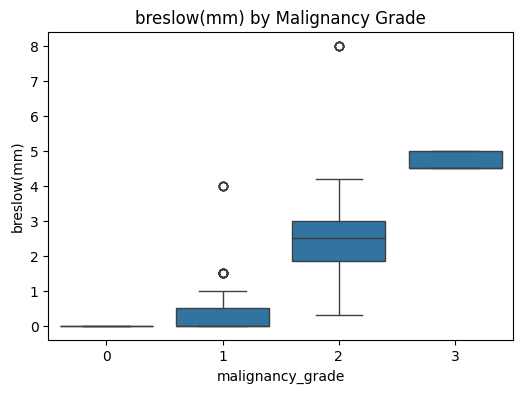

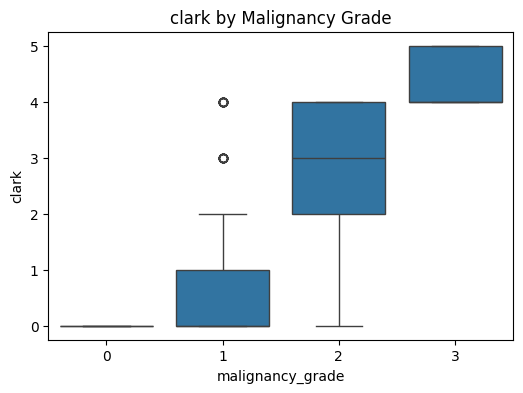

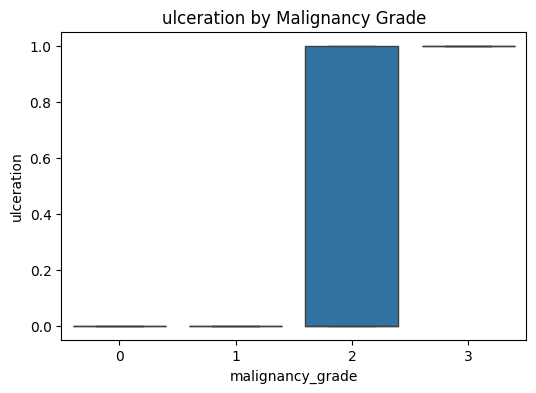

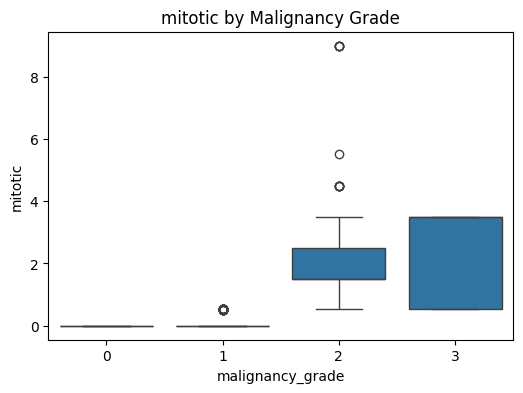

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

features = ['breslow(mm)', 'clark', 'ulceration', 'mitotic']

for feature in features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='malignancy_grade', y=feature, data=train_df)
    plt.title(f'{feature} by Malignancy Grade')
    plt.show()

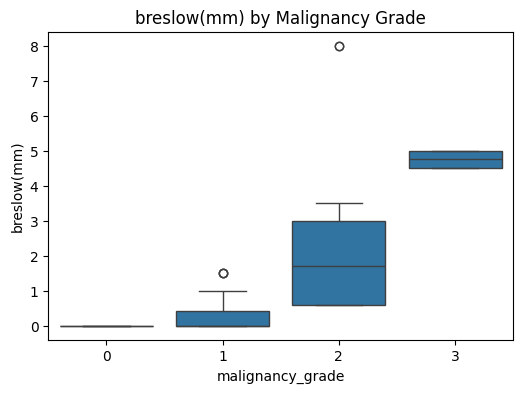

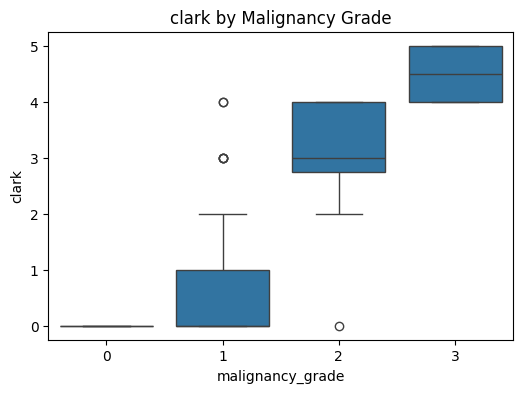

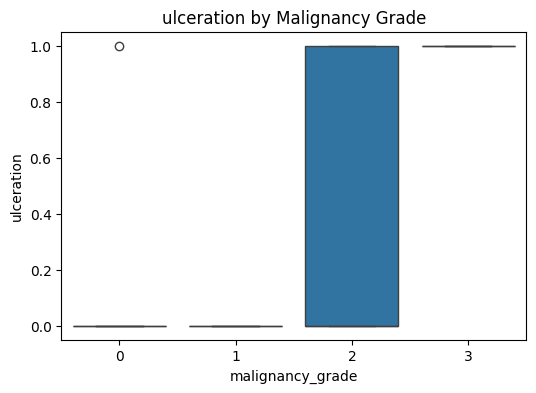

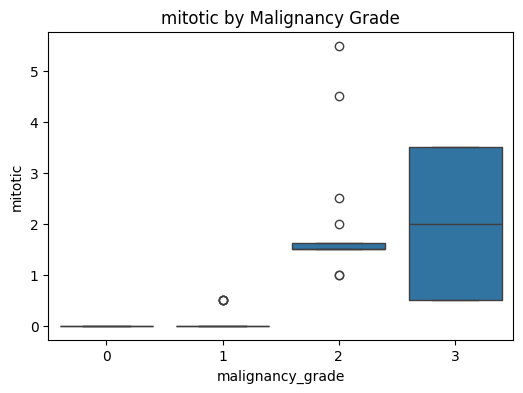

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

features = ['breslow(mm)', 'clark', 'ulceration', 'mitotic']

for feature in features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='malignancy_grade', y=feature, data=validation_df)
    plt.title(f'{feature} by Malignancy Grade')
    plt.show()

In [ ]:
import pandas as pd
import numpy as np
import os
from tensorflow.keras.applications import Xception
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tqdm import tqdm

train_df = pd.read_excel('/content/train_with_malignancy_grade.xlsx')
val_df = pd.read_excel('/content/validation_with_malignancy_grade.xlsx')

train_df = train_df[~train_df['malignancy_grade'].isna()]
val_df = val_df[~val_df['malignancy_grade'].isna()]

train_df['malignancy_grade'] = train_df['malignancy_grade'].astype(int)
val_df['malignancy_grade'] = val_df['malignancy_grade'].astype(int)

all_df = pd.concat([train_df, val_df], ignore_index=True)
all_labels = all_df['malignancy_grade'].values
all_paths = all_df['image_path'].values

def load_and_preprocess_image(path):
    try:
        img = load_img(path, target_size=(224, 224))
        img_array = img_to_array(img)
        img_array = tf.keras.applications.xception.preprocess_input(img_array)
        return img_array
    except:
        print(f" خطا در بارگذاری تصویر: {path}")
        return None

print(" در حال بارگذاری و پیش‌پردازش تصاویر...")
images = []
valid_labels = []

for i, (img_path, label) in enumerate(tqdm(zip(all_paths, all_labels), total=len(all_paths))):
    img_array = load_and_preprocess_image(img_path)
    if img_array is not None:
        images.append(img_array)
        valid_labels.append(label)

images = np.array(images)
labels = to_categorical(valid_labels, num_classes=4)

print(" استخراج ویژگی‌ها با Xception...")
base_model = Xception(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
features = base_model.predict(images, verbose=1)

X_flat = features.reshape(features.shape[0], -1)
y_raw = np.argmax(labels, axis=1)

print(" اعمال SMOTE برای تعادل داده‌ها...")
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_flat, y_raw)

y_resampled_cat = to_categorical(y_resampled, num_classes=4)
X_resampled = X_resampled.reshape(-1, 7, 7, 2048)

X_train, X_val, y_train, y_val = train_test_split(
    X_resampled, y_resampled_cat, test_size=0.2, random_state=42, stratify=y_resampled
)

class_weights = compute_class_weight('balanced', classes=np.unique(y_resampled), y=y_resampled)
class_weights_dict = {i: weight for i, weight in enumerate(class_weights)}

model = models.Sequential([
    layers.Input(shape=(7, 7, 2048)),
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4),
    layers.Dense(512, kernel_regularizer=l2(0.0005)),
    layers.BatchNormalization(),
    layers.LeakyReLU(),
    layers.Dropout(0.3),
    layers.Dense(4, activation='softmax')  # 4 کلاس
])

model.compile(optimizer=Adam(learning_rate=3e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

early_stopping = EarlyStopping(patience=7, monitor='val_loss', restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-7)
checkpoint = ModelCheckpoint('malignancy_grading_model.keras', monitor='val_accuracy', save_best_only=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[early_stopping, reduce_lr, checkpoint],
    verbose=1
)

val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
print(f"\n Validation Accuracy: {val_acc:.4f}")
print(f" Validation Loss: {val_loss:.4f}")
y_pred = model.predict(X_val)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_val, axis=1)

print("\n Classification Report:\n")
print(classification_report(y_true_classes, y_pred_classes))

✅ در حال بارگذاری و پیش‌پردازش تصاویر...


 26%|██▋       | 160/608 [00:17<00:15, 29.30it/s]

❌ خطا در بارگذاری تصویر: /content/drive/MyDrive/train/malignant/p1 .jpg


100%|██████████| 608/608 [01:33<00:00,  6.49it/s]


📦 استخراج ویژگی‌ها با Xception...
19/19 ━━━━━━━━━━━━━━━━━━━━ 172s 9s/step
📈 اعمال SMOTE برای تعادل داده‌ها...
Epoch 1/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - accuracy: 0.3116 - loss: 2.1009 - val_accuracy: 0.5804 - val_loss: 1.5335 - learning_rate: 3.0000e-05
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.5324 - loss: 1.6245 - val_accuracy: 0.6652 - val_loss: 1.3456 - learning_rate: 3.0000e-05
Epoch 3/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.5764 - loss: 1.4556 - val_accuracy: 0.6875 - val_loss: 1.2524 - learning_rate: 3.0000e-05
Epoch 4/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.6446 - loss: 1.3191 - val_accuracy: 0.6830 - val_loss: 1.1881 - learning_rate: 3.0000e-05
Epoch 5/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.6691 - loss: 1.2334 - val_accuracy: 0.7009 - val_loss: 1.1462 - learning_rate: 3.0000e-05
Epoch 6/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.6910 - loss: 1.2099 - val_accuracy: 0.7143 -

In [ ]:
import pandas as pd

train_df = pd.read_excel('/content/train_with_image_paths.xlsx')
val_df = pd.read_excel('/content/validation_with_image_paths.xlsx')

def determine_malignancy(row):
    if row['diagnosis'] == 0:
        return 0

    # Breslow Depth
    breslow = row['breslow(mm)']
    if pd.isna(breslow):
        breslow_grade = 1
    elif breslow == 0:
        breslow_grade = 1
    elif 1 <= breslow <= 4:
        breslow_grade = 2
    else:
        breslow_grade = 3

    # Clark Level
    clark = row['clark']
    if pd.isna(clark):
        clark_grade = 1
    elif clark <= 2:
        clark_grade = 1
    elif 3 <= clark <= 4:
        clark_grade = 2
    else:
        clark_grade = 3

    # Ulceration
    ulceration = row['ulceration']
    if pd.isna(ulceration) or ulceration == 0:
        ulceration_grade = 1
    else:
        ulceration_grade = 3

    # Mitotic Activity
    mitotic = row['mitotic']
    if pd.isna(mitotic) or mitotic < 1:
        mitotic_grade = 1
    elif 1 <= mitotic < 3:
        mitotic_grade = 2
    else:
        mitotic_grade = 3

    final_score = breslow_grade + clark_grade + ulceration_grade + mitotic_grade

    if final_score >= 10:
        return 3
    elif 7 <= final_score < 10:
        return 2
    else:
        return 1

train_df['malignancy_grade'] = train_df.apply(determine_malignancy, axis=1)
val_df['malignancy_grade'] = val_df.apply(determine_malignancy, axis=1)

train_df.to_excel('/content/train_with_malignancy_grade.xlsx', index=False)
val_df.to_excel('/content/validation_with_malignancy_grade.xlsx', index=False)

print(" ستون malignancy_grade با موفقیت اضافه و ذخیره شد.")

✅ ستون malignancy_grade با موفقیت اضافه و ذخیره شد.


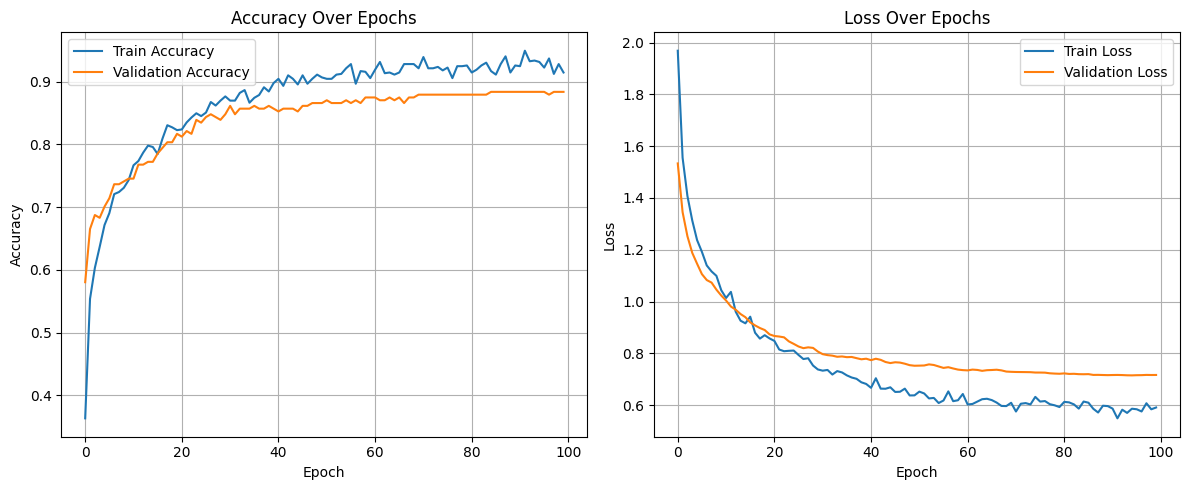

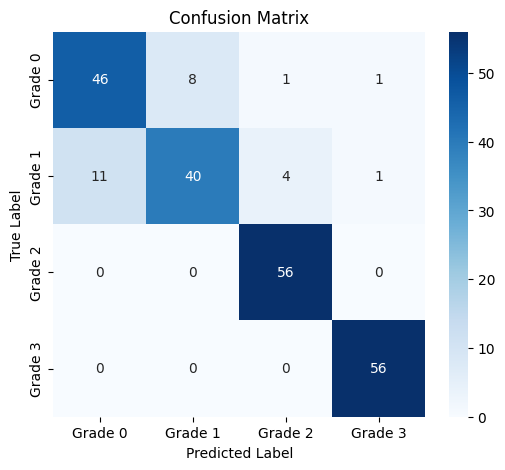

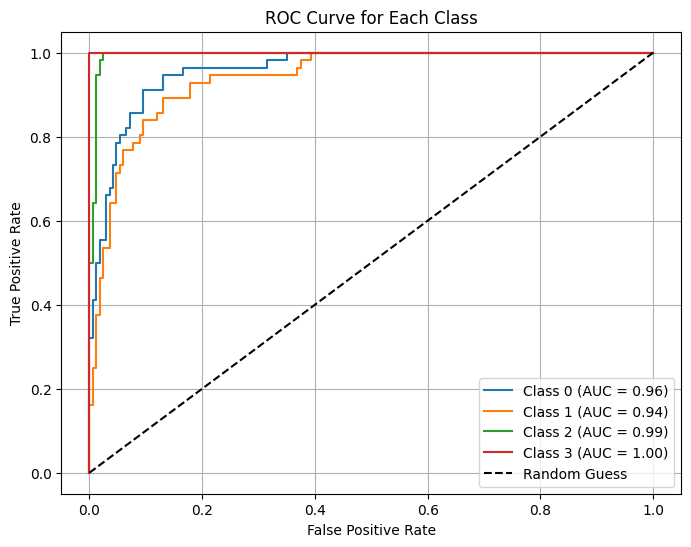

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true_classes, y_pred_classes)
labels = ['Grade 0', 'Grade 1', 'Grade 2', 'Grade 3']

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_val_bin = label_binarize(y_true_classes, classes=[0, 1, 2, 3])
y_pred_bin = y_pred

fpr = {}
tpr = {}
roc_auc = {}
n_classes = 4

plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_val_bin[:, i], y_pred_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.title('ROC Curve for Each Class')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()



🔁 Fold 1
Epoch 1/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 11s 151ms/step - accuracy: 0.3351 - loss: 2.1648 - val_accuracy: 0.4955 - val_loss: 1.5232 - learning_rate: 3.0000e-05
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 117ms/step - accuracy: 0.4764 - loss: 1.6813 - val_accuracy: 0.6339 - val_loss: 1.3496 - learning_rate: 3.0000e-05
Epoch 3/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.5886 - loss: 1.4631 - val_accuracy: 0.6696 - val_loss: 1.2516 - learning_rate: 3.0000e-05
Epoch 4/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.6562 - loss: 1.3109 - val_accuracy: 0.6875 - val_loss: 1.1782 - learning_rate: 3.0000e-05
Epoch 5/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.6319 - loss: 1.3577 - val_accuracy: 0.7054 - val_loss: 1.1177 - learning_rate: 3.0000e-05
Epoch 6/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.6720 - loss: 1.1789 - val_accuracy: 0.7232 - val_loss: 1.0700 - learning_rate: 3.0000e-05
Epoch 7/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step

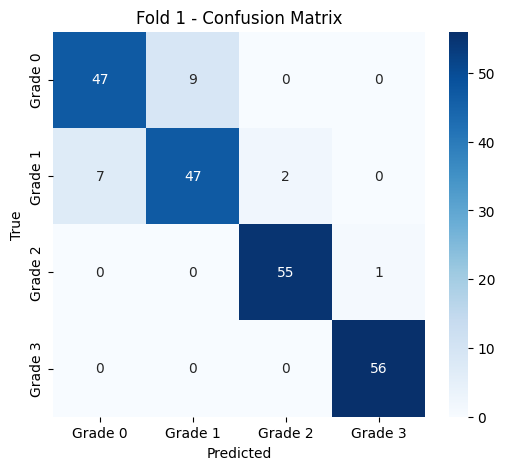

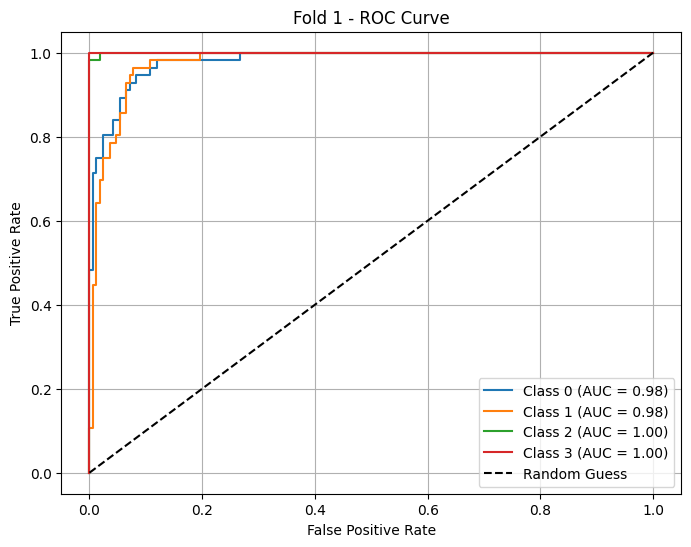


🔁 Fold 2
Epoch 1/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - accuracy: 0.2947 - loss: 2.1914 - val_accuracy: 0.5830 - val_loss: 1.5471 - learning_rate: 3.0000e-05
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.5258 - loss: 1.6163 - val_accuracy: 0.6457 - val_loss: 1.3452 - learning_rate: 3.0000e-05
Epoch 3/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.5714 - loss: 1.4887 - val_accuracy: 0.6861 - val_loss: 1.2405 - learning_rate: 3.0000e-05
Epoch 4/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.6464 - loss: 1.3479 - val_accuracy: 0.7040 - val_loss: 1.1694 - learning_rate: 3.0000e-05
Epoch 5/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.6589 - loss: 1.2826 - val_accuracy: 0.7220 - val_loss: 1.1228 - learning_rate: 3.0000e-05
Epoch 6/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.7082 - loss: 1.1535 - val_accuracy: 0.7399 - val_loss: 1.0827 - learning_rate: 3.0000e-05
Epoch 7/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - 

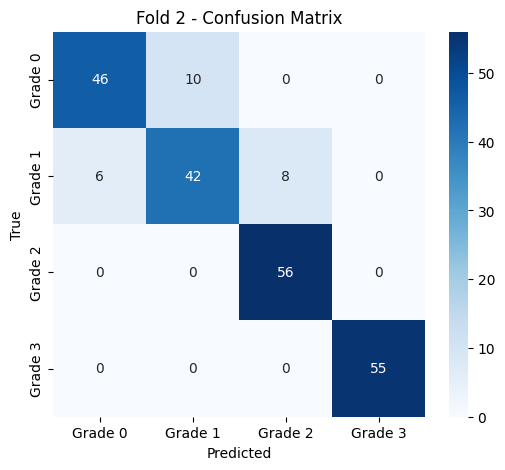

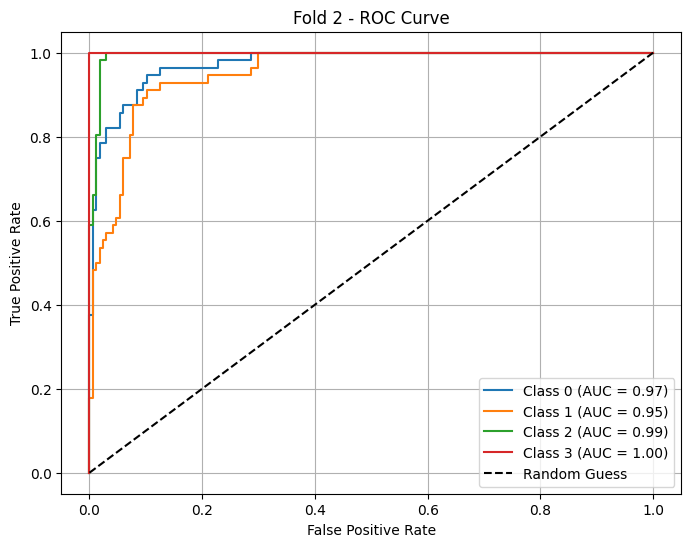


🔁 Fold 3
Epoch 1/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - accuracy: 0.2972 - loss: 2.0888 - val_accuracy: 0.5830 - val_loss: 1.5017 - learning_rate: 3.0000e-05
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.4924 - loss: 1.6312 - val_accuracy: 0.6502 - val_loss: 1.3044 - learning_rate: 3.0000e-05
Epoch 3/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - accuracy: 0.5990 - loss: 1.4329 - val_accuracy: 0.7175 - val_loss: 1.1976 - learning_rate: 3.0000e-05
Epoch 4/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.6435 - loss: 1.3002 - val_accuracy: 0.7354 - val_loss: 1.1295 - learning_rate: 3.0000e-05
Epoch 5/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.6970 - loss: 1.2027 - val_accuracy: 0.7444 - val_loss: 1.0822 - learning_rate: 3.0000e-05
Epoch 6/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.6978 - loss: 1.1684 - val_accuracy: 0.7444 - val_loss: 1.0477 - learning_rate: 3.0000e-05
Epoch 7/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - 

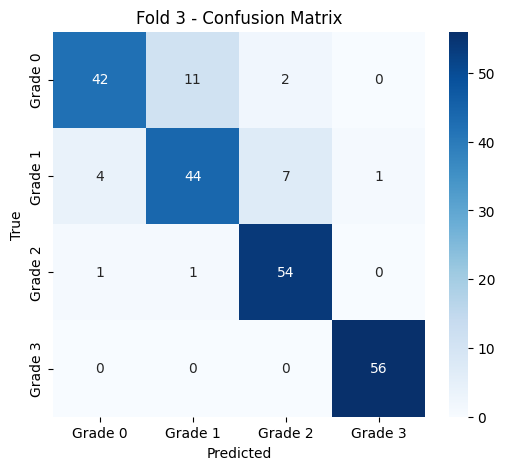

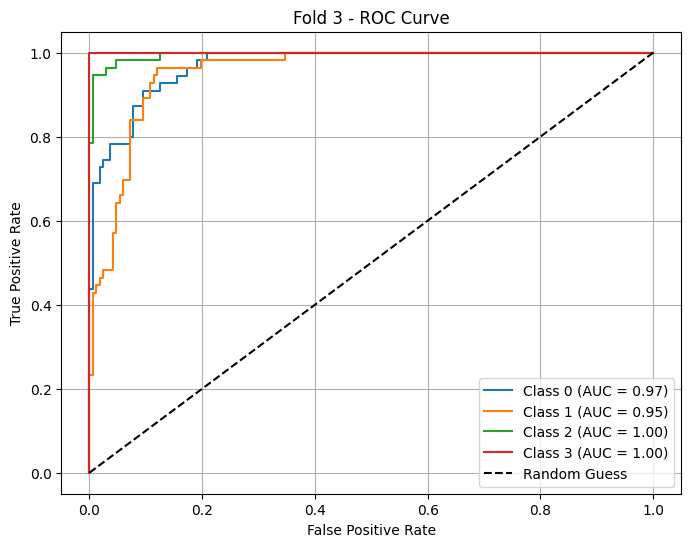


🔁 Fold 4
Epoch 1/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 9s 102ms/step - accuracy: 0.2961 - loss: 2.1108 - val_accuracy: 0.5919 - val_loss: 1.4705 - learning_rate: 3.0000e-05
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.4983 - loss: 1.6154 - val_accuracy: 0.6637 - val_loss: 1.3080 - learning_rate: 3.0000e-05
Epoch 3/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.6028 - loss: 1.3967 - val_accuracy: 0.6906 - val_loss: 1.2170 - learning_rate: 3.0000e-05
Epoch 4/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.6355 - loss: 1.3278 - val_accuracy: 0.7085 - val_loss: 1.1590 - learning_rate: 3.0000e-05
Epoch 5/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.6588 - loss: 1.2590 - val_accuracy: 0.7130 - val_loss: 1.1116 - learning_rate: 3.0000e-05
Epoch 6/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.6772 - loss: 1.2025 - val_accuracy: 0.7265 - val_loss: 1.0824 - learning_rate: 3.0000e-05
Epoch 7/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step -

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 185ms/step

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.79      0.84        56
           1       0.83      0.82      0.83        55
           2       0.92      1.00      0.96        56
           3       0.95      1.00      0.97        56

    accuracy                           0.90       223
   macro avg       0.90      0.90      0.90       223
weighted avg       0.90      0.90      0.90       223



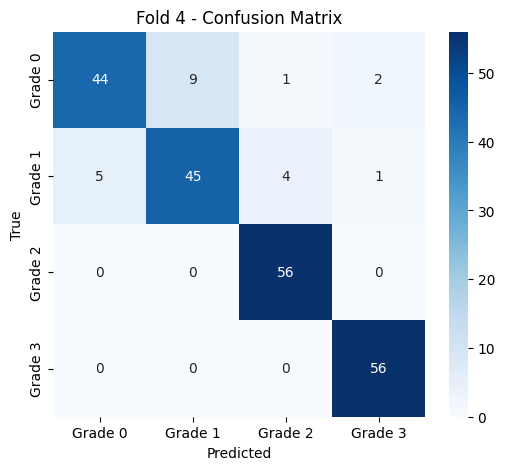

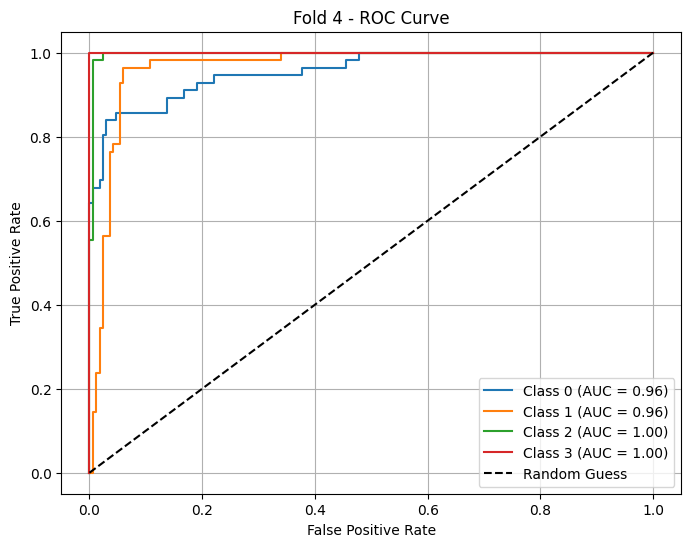


🔁 Fold 5
Epoch 1/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - accuracy: 0.2794 - loss: 2.1588 - val_accuracy: 0.4978 - val_loss: 1.4990 - learning_rate: 3.0000e-05
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step - accuracy: 0.5159 - loss: 1.5124 - val_accuracy: 0.7354 - val_loss: 1.2833 - learning_rate: 3.0000e-05
Epoch 3/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.6098 - loss: 1.4163 - val_accuracy: 0.7175 - val_loss: 1.1776 - learning_rate: 3.0000e-05
Epoch 4/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.6684 - loss: 1.2742 - val_accuracy: 0.7354 - val_loss: 1.1156 - learning_rate: 3.0000e-05
Epoch 5/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.6825 - loss: 1.1825 - val_accuracy: 0.7175 - val_loss: 1.0861 - learning_rate: 3.0000e-05
Epoch 6/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.7037 - loss: 1.1690 - val_accuracy: 0.7130 - val_loss: 1.0644 - learning_rate: 3.0000e-05
Epoch 7/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - 

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.77      0.77        56
           1       0.77      0.77      0.77        56
           2       0.93      0.95      0.94        55
           3       1.00      1.00      1.00        56

    accuracy                           0.87       223
   macro avg       0.87      0.87      0.87       223
weighted avg       0.87      0.87      0.87       223



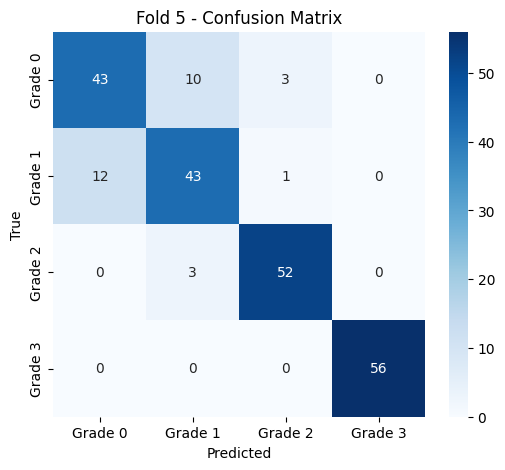

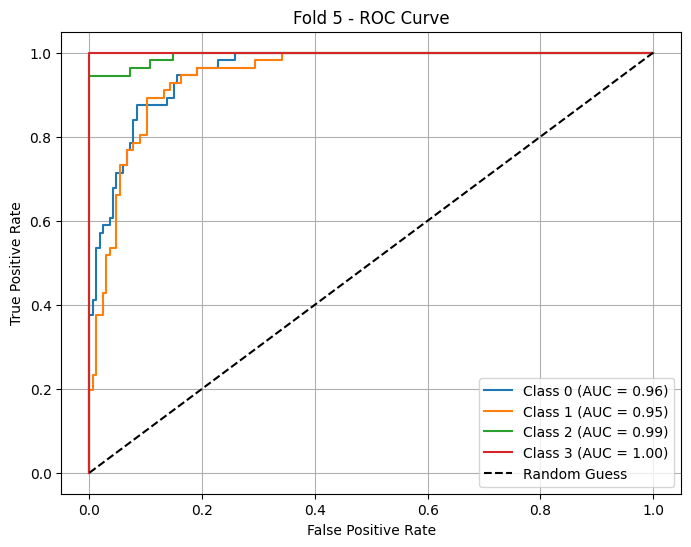


🔚 Cross-Validation Summary:
✅ Average Accuracy: 0.8916 ± 0.0160
✅ Average Loss: 0.6629 ± 0.0492


In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

NUM_FOLDS = 5
BATCH_SIZE = 32
EPOCHS = 100
N_CLASSES = 4
fold = 1

all_fold_acc = []
all_fold_loss = []

skf = StratifiedKFold(n_splits=NUM_FOLDS, shuffle=True, random_state=42)

for train_index, val_index in skf.split(X_resampled, y_resampled):
    print(f"\n Fold {fold}")

    X_train, X_val = X_resampled[train_index], X_resampled[val_index]
    y_train, y_val = y_resampled_cat[train_index], y_resampled_cat[val_index]
    y_val_labels = y_resampled[val_index]

    # کلاس وزن‌ها
    class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_resampled), y=y_resampled[train_index])
    class_weights_dict = {i: w for i, w in enumerate(class_weights)}

    model = models.Sequential([
        layers.Input(shape=(7, 7, 2048)),
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.4),
        layers.Dense(512, kernel_regularizer=l2(0.0005)),
        layers.BatchNormalization(),
        layers.LeakyReLU(),
        layers.Dropout(0.3),
        layers.Dense(N_CLASSES, activation='softmax')
    ])
    model.compile(optimizer=Adam(learning_rate=3e-5), loss='categorical_crossentropy', metrics=['accuracy'])

    early_stopping = EarlyStopping(patience=7, monitor='val_loss', restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-7)
    checkpoint = ModelCheckpoint(f'model_fold_{fold}.keras', monitor='val_accuracy', save_best_only=True)

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        class_weight=class_weights_dict,
        callbacks=[early_stopping, reduce_lr, checkpoint],
        verbose=1
    )

    val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
    all_fold_acc.append(val_acc)
    all_fold_loss.append(val_loss)
    print(f" Fold {fold} Accuracy: {val_acc:.4f} | Loss: {val_loss:.4f}")

    y_pred = model.predict(X_val)
    y_pred_classes = np.argmax(y_pred, axis=1)
    print("\n Classification Report:")
    print(classification_report(y_val_labels, y_pred_classes))

    cm = confusion_matrix(y_val_labels, y_pred_classes)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[f'Grade {i}' for i in range(N_CLASSES)],
                yticklabels=[f'Grade {i}' for i in range(N_CLASSES)])
    plt.title(f'Fold {fold} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    y_val_bin = label_binarize(y_val_labels, classes=[0, 1, 2, 3])
    plt.figure(figsize=(8, 6))
    fpr = {}
    tpr = {}
    roc_auc = {}

    for i in range(N_CLASSES):
        fpr[i], tpr[i], _ = roc_curve(y_val_bin[:, i], y_pred[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
    plt.title(f'Fold {fold} - ROC Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

    fold += 1

print("\n Cross-Validation Summary:")
print(f" Average Accuracy: {np.mean(all_fold_acc):.4f} ± {np.std(all_fold_acc):.4f}")
print(f" Average Loss: {np.mean(all_fold_loss):.4f} ± {np.std(all_fold_loss):.4f}")

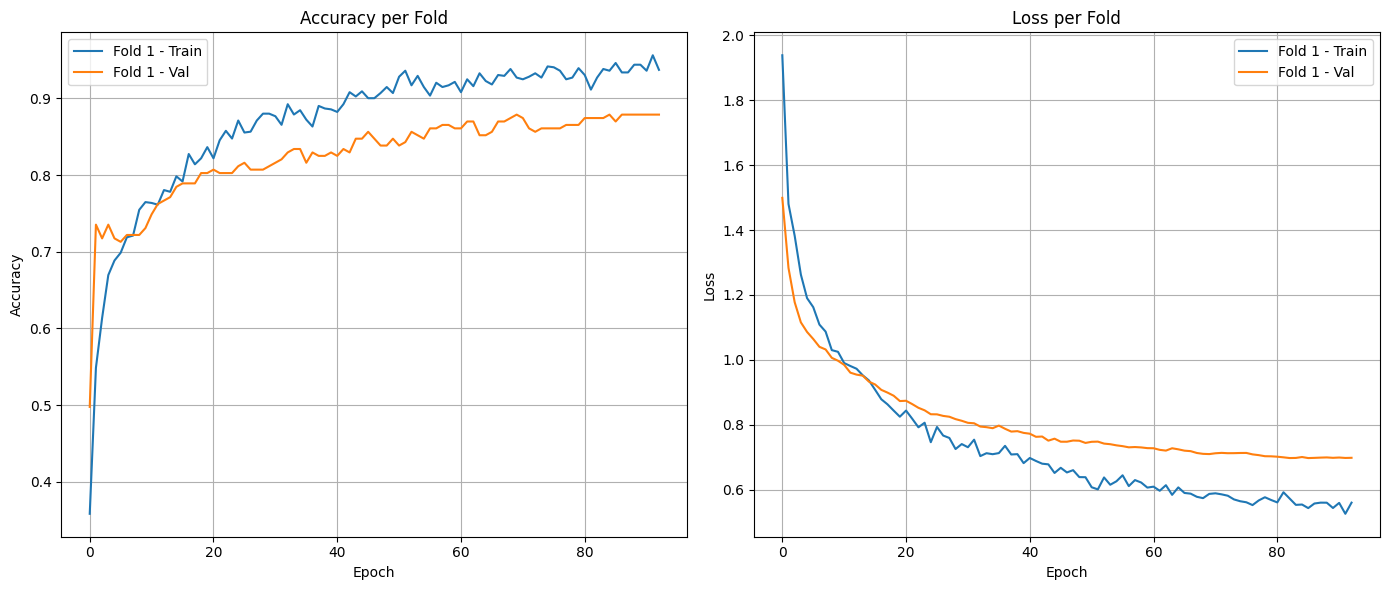

In [ ]:
all_history_acc = []
all_history_val_acc = []
all_history_loss = []
all_history_val_loss = []
history_acc = history.history['accuracy']
history_val_acc = history.history['val_accuracy']
history_loss = history.history['loss']
history_val_loss = history.history['val_loss']

all_history_acc.append(history_acc)
all_history_val_acc.append(history_val_acc)
all_history_loss.append(history_loss)
all_history_val_loss.append(history_val_loss)

import matplotlib.pyplot as plt
max_epochs = max(len(h) for h in all_history_acc)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
for i, acc in enumerate(all_history_acc):
    plt.plot(acc, label=f'Fold {i+1} - Train')
for i, val_acc in enumerate(all_history_val_acc):
    plt.plot(val_acc, label=f'Fold {i+1} - Val')
plt.title('Accuracy per Fold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
for i, loss in enumerate(all_history_loss):
    plt.plot(loss, label=f'Fold {i+1} - Train')
for i, val_loss in enumerate(all_history_val_loss):
    plt.plot(val_loss, label=f'Fold {i+1} - Val')
plt.title('Loss per Fold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras.applications import Xception
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tqdm import tqdm

train_df = pd.read_excel('/content/train_with_malignancy_grade.xlsx')
val_df = pd.read_excel('/content/validation_with_malignancy_grade.xlsx')

train_df = train_df[~train_df['diagnosis'].isna()]
val_df = val_df[~val_df['diagnosis'].isna()]

train_df['diagnosis'] = train_df['diagnosis'].astype(int)
val_df['diagnosis'] = val_df['diagnosis'].astype(int)

all_df = pd.concat([train_df, val_df], ignore_index=True)
all_labels = all_df['diagnosis'].values
all_paths = all_df['image_path'].values

def load_and_preprocess_image(path):
    try:
        img = load_img(path, target_size=(224, 224))
        img_array = img_to_array(img)
        img_array = tf.keras.applications.xception.preprocess_input(img_array)
        return img_array
    except:
        print(f" خطا در بارگذاری تصویر: {path}")
        return None

print(" در حال بارگذاری و پیش‌پردازش تصاویر...")
images = []
valid_labels = []

for img_path, label in tqdm(zip(all_paths, all_labels), total=len(all_paths)):
    img_array = load_and_preprocess_image(img_path)
    if img_array is not None:
        images.append(img_array)
        valid_labels.append(label)

images = np.array(images)
labels = np.array(valid_labels)

print(" استخراج ویژگی‌ها با Xception...")
base_model = Xception(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
features = base_model.predict(images, verbose=1)

X_flat = features.reshape(features.shape[0], -1)
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_flat, labels)

X_resampled = X_resampled.reshape(-1, 7, 7, 2048)
y_resampled = np.array(y_resampled)

X_train, X_val, y_train, y_val = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled
)

class_weights = compute_class_weight('balanced', classes=np.unique(y_resampled), y=y_resampled)
class_weights_dict = {i: weight for i, weight in enumerate(class_weights)}

model = models.Sequential([
    layers.Input(shape=(7, 7, 2048)),
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4),
    layers.Dense(512, kernel_regularizer=l2(0.0005)),
    layers.BatchNormalization(),
    layers.LeakyReLU(),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer=Adam(learning_rate=3e-5),
              loss='binary_crossentropy',
              metrics=['accuracy'])

early_stopping = EarlyStopping(patience=7, monitor='val_loss', restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-7)
checkpoint = ModelCheckpoint('diagnosis_binary_model.keras', monitor='val_accuracy', save_best_only=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[early_stopping, reduce_lr, checkpoint],
    verbose=1
)

val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
print(f"\n Validation Accuracy: {val_acc:.4f}")
print(f" Validation Loss: {val_loss:.4f}")

y_pred_probs = model.predict(X_val)
y_pred_classes = (y_pred_probs > 0.5).astype(int).reshape(-1)

print("\n Classification Report:\n")
print(classification_report(y_val, y_pred_classes))

✅ در حال بارگذاری و پیش‌پردازش تصاویر...


 26%|██▌       | 158/608 [00:09<00:20, 22.04it/s]

❌ خطا در بارگذاری تصویر: /content/drive/MyDrive/train/malignant/p1 .jpg


100%|██████████| 608/608 [00:22<00:00, 27.58it/s]


📦 استخراج ویژگی‌ها با Xception...
19/19 ━━━━━━━━━━━━━━━━━━━━ 166s 9s/step
Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - accuracy: 0.5040 - loss: 1.2043 - val_accuracy: 0.6818 - val_loss: 1.0267 - learning_rate: 3.0000e-05
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.6607 - loss: 1.0531 - val_accuracy: 0.7273 - val_loss: 0.9645 - learning_rate: 3.0000e-05
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.7424 - loss: 0.9555 - val_accuracy: 0.7500 - val_loss: 0.9294 - learning_rate: 3.0000e-05
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.7225 - loss: 0.9400 - val_accuracy: 0.7576 - val_loss: 0.9039 - learning_rate: 3.0000e-05
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.7308 - loss: 0.9323 - val_accuracy: 0.7727 - val_loss: 0.8845 - learning_rate: 3.0000e-05
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.7400 - loss: 0.9113 - val_accuracy: 0.7955 - val_loss: 0.8723 - learning_rate: 3

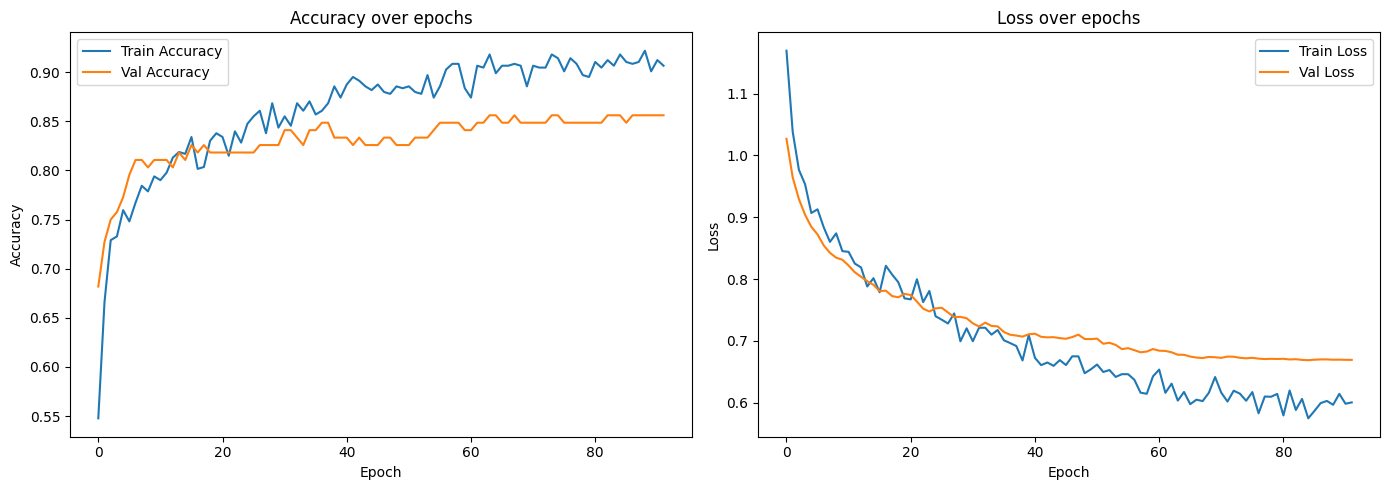

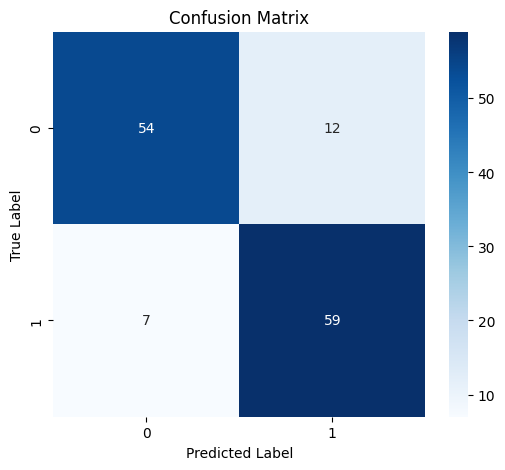

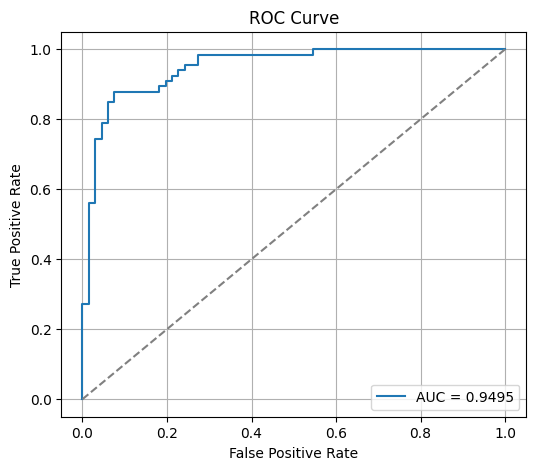

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc
import seaborn as sns

def plot_accuracy_loss(history):
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Accuracy over epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Loss over epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_accuracy_loss(history)

def plot_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()

plot_confusion_matrix(y_val, y_pred_classes)

def plot_roc(y_true, y_probs):
    fpr, tpr, thresholds = roc_curve(y_true, y_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

plot_roc(y_val, y_pred_probs)


🔁 Fold 1/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


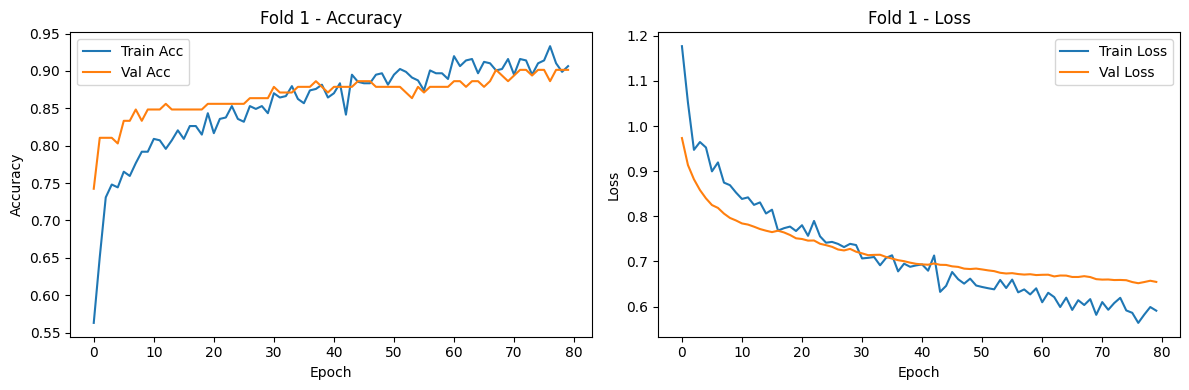

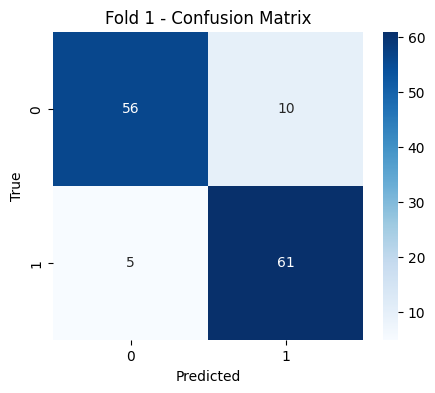

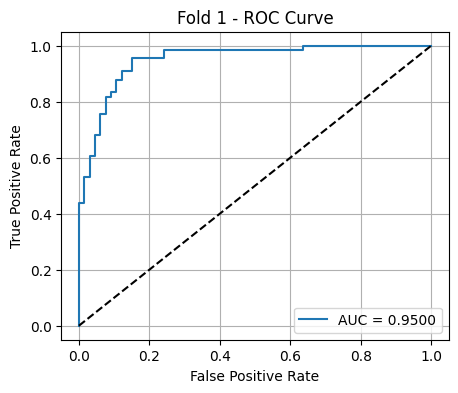


📊 Fold 1 - Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.85      0.88        66
           1       0.86      0.92      0.89        66

    accuracy                           0.89       132
   macro avg       0.89      0.89      0.89       132
weighted avg       0.89      0.89      0.89       132


🔁 Fold 2/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


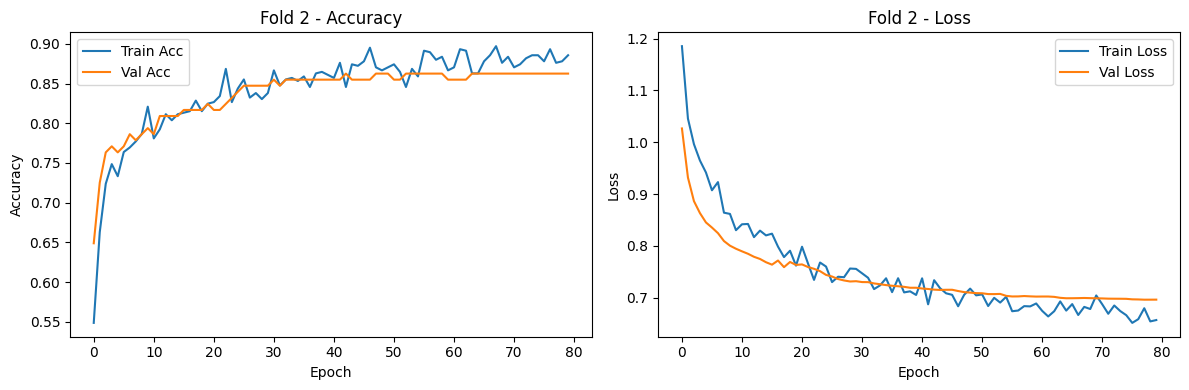

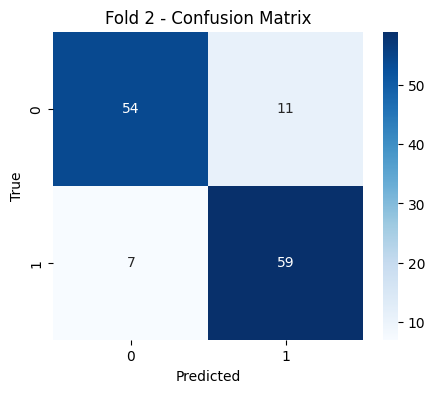

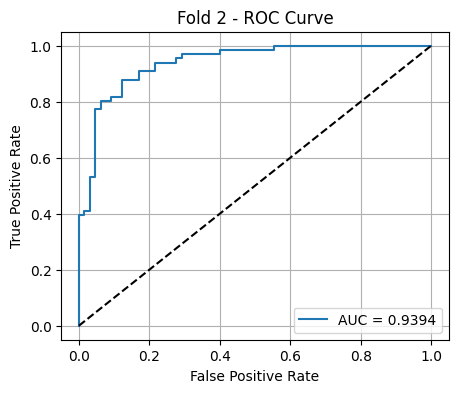


📊 Fold 2 - Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.83      0.86        65
           1       0.84      0.89      0.87        66

    accuracy                           0.86       131
   macro avg       0.86      0.86      0.86       131
weighted avg       0.86      0.86      0.86       131


🔁 Fold 3/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


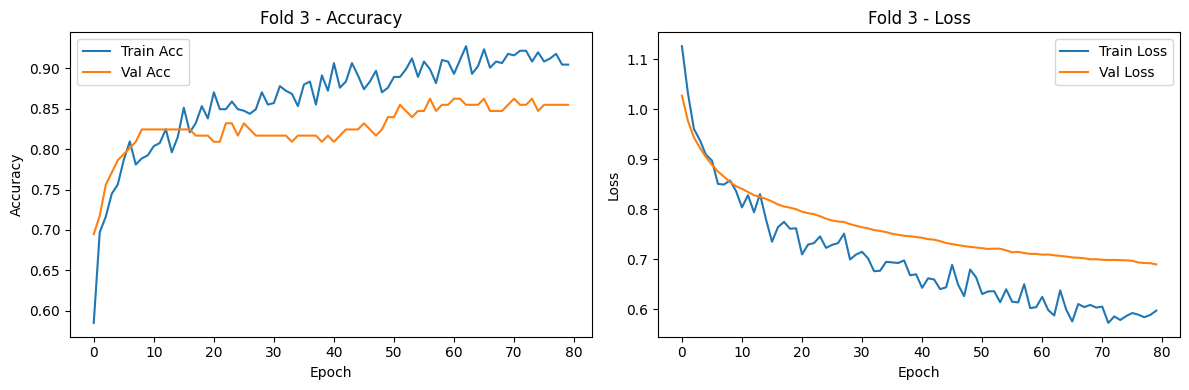

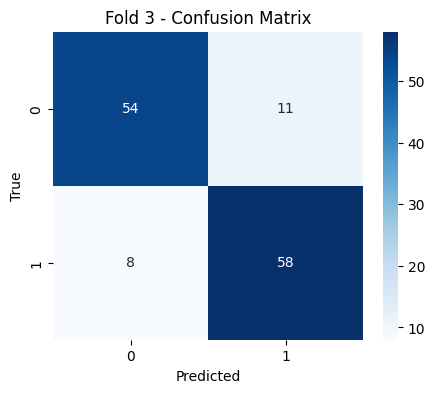

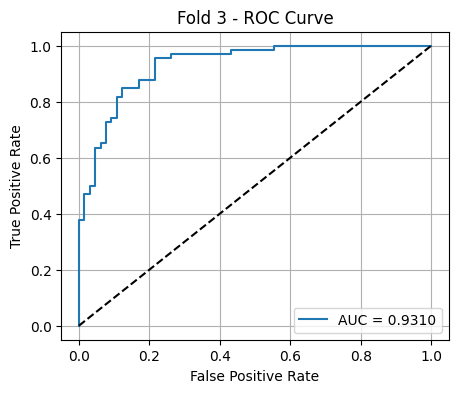


📊 Fold 3 - Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.83      0.85        65
           1       0.84      0.88      0.86        66

    accuracy                           0.85       131
   macro avg       0.86      0.85      0.85       131
weighted avg       0.86      0.85      0.85       131


🔁 Fold 4/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


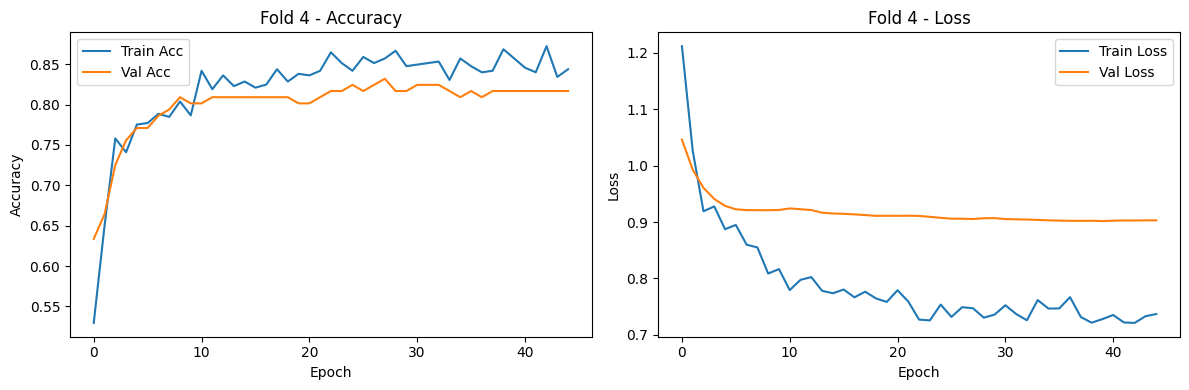

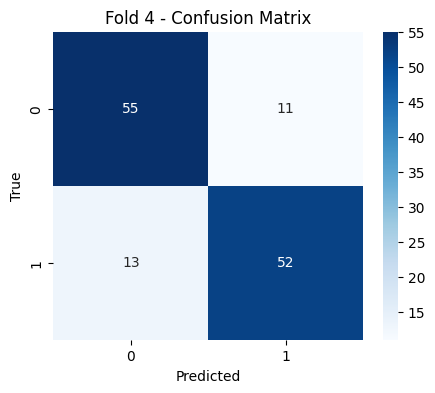

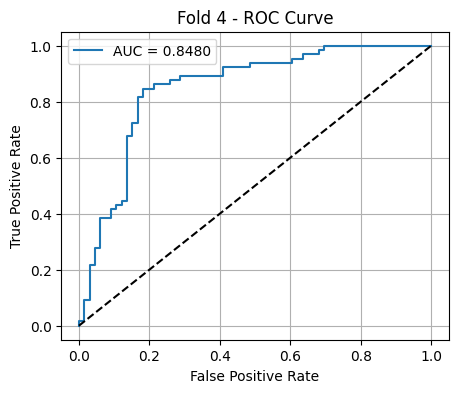


📊 Fold 4 - Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.83      0.82        66
           1       0.83      0.80      0.81        65

    accuracy                           0.82       131
   macro avg       0.82      0.82      0.82       131
weighted avg       0.82      0.82      0.82       131


🔁 Fold 5/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


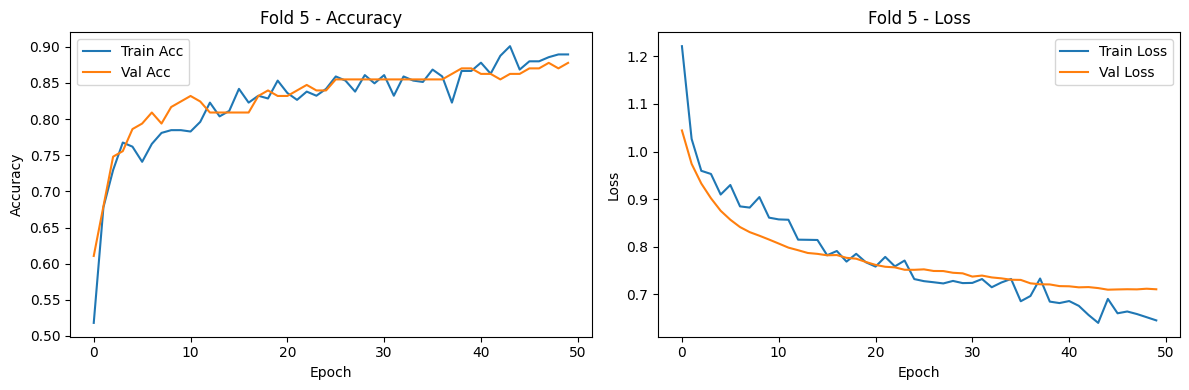

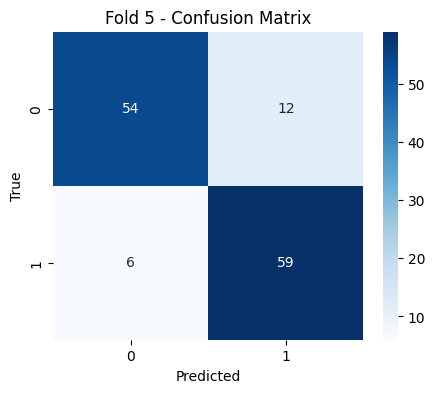

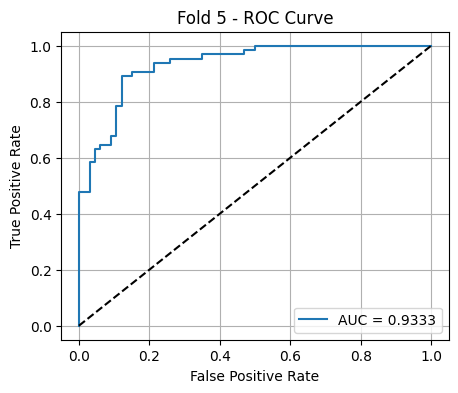


📊 Fold 5 - Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.82      0.86        66
           1       0.83      0.91      0.87        65

    accuracy                           0.86       131
   macro avg       0.87      0.86      0.86       131
weighted avg       0.87      0.86      0.86       131



In [ ]:
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report
import seaborn as sns
import numpy as np

def plot_accuracy_loss(history, fold):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title(f'Fold {fold+1} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'Fold {fold+1} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(y_true, y_pred, fold):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Fold {fold+1} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

def plot_roc(y_true, y_probs, fold):
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f'Fold {fold+1} - ROC Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.grid(True)
    plt.show()

from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

k = 5
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_resampled, y_resampled)):
    print(f"\n Fold {fold+1}/{k}")

    X_train, X_val = X_resampled[train_idx], X_resampled[val_idx]
    y_train, y_val = y_resampled[train_idx], y_resampled[val_idx]

    class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    class_weights_dict = {i: w for i, w in enumerate(class_weights)}

    K.clear_session()
    model = models.Sequential([
        layers.Input(shape=(7, 7, 2048)),
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.4),
        layers.Dense(512, kernel_regularizer=l2(0.0005)),
        layers.BatchNormalization(),
        layers.LeakyReLU(),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer=Adam(learning_rate=3e-5),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

    early_stopping = EarlyStopping(patience=5, monitor='val_loss', restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7)

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=80,
        batch_size=32,
        class_weight=class_weights_dict,
        callbacks=[early_stopping, reduce_lr],
        verbose=0
    )
    y_pred_probs = model.predict(X_val).reshape(-1)
    y_pred_classes = (y_pred_probs > 0.5).astype(int)

    plot_accuracy_loss(history, fold)
    plot_confusion_matrix(y_val, y_pred_classes, fold)
    plot_roc(y_val, y_pred_probs, fold)

    print(f"\n Fold {fold+1} - Classification Report:\n")
    print(classification_report(y_val, y_pred_classes))

In [ ]:
############ fusion #####

 28%|██▊       | 169/608 [00:01<00:04, 95.84it/s]

❌ مشکل در بارگذاری: /content/drive/MyDrive/train/malignant/p1 .jpg


100%|██████████| 608/608 [00:06<00:00, 98.80it/s]


19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 268ms/step
Epoch 1/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 9s 146ms/step - accuracy: 0.2089 - loss: 2.9255 - val_accuracy: 0.5045 - val_loss: 1.6943 - learning_rate: 3.0000e-05
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.4298 - loss: 2.0012 - val_accuracy: 0.6250 - val_loss: 1.4587 - learning_rate: 3.0000e-05
Epoch 3/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.5481 - loss: 1.5912 - val_accuracy: 0.7009 - val_loss: 1.2932 - learning_rate: 3.0000e-05
Epoch 4/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.6471 - loss: 1.4276 - val_accuracy: 0.7589 - val_loss: 1.1808 - learning_rate: 3.0000e-05
Epoch 5/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.6906 - loss: 1.3010 - val_accuracy: 0.8080 - val_loss: 1.0861 - learning_rate: 3.0000e-05
Epoch 6/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.6993 - loss: 1.2570 - val_accuracy: 0.8214 - val_loss: 1.0092 - learning_rate: 3.0000e-05
Epoch 7/100
28/28 ━━━━

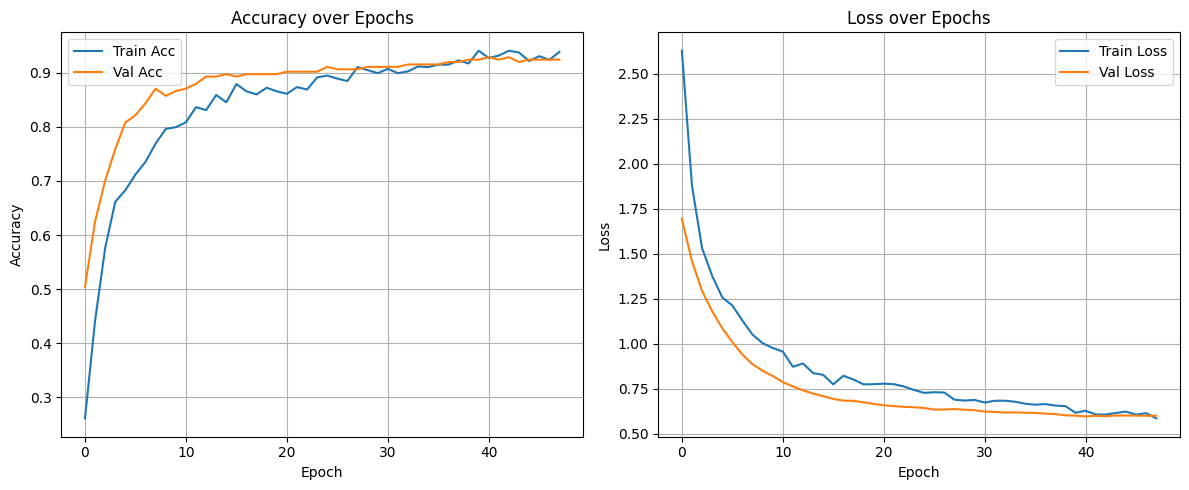

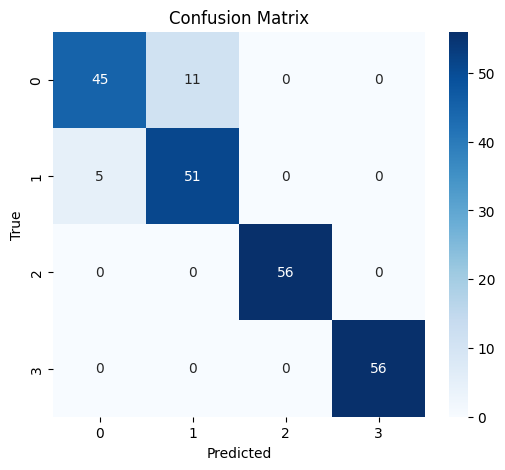

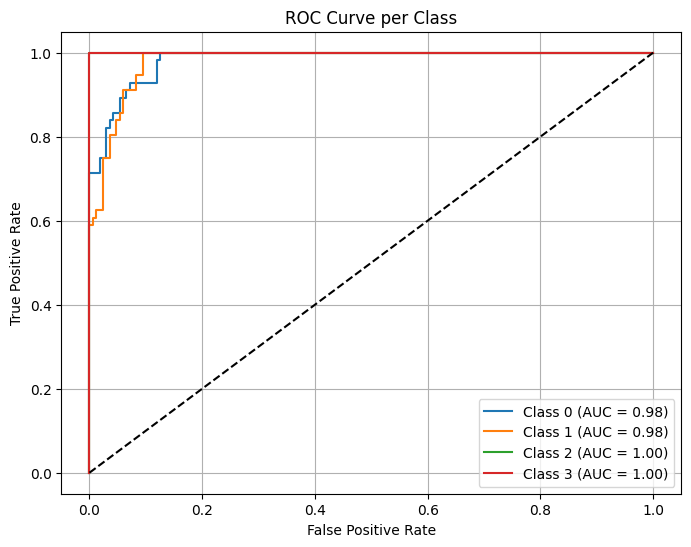

In [ ]:
import pandas as pd
import numpy as np
import os
from tensorflow.keras.applications import Xception
from tensorflow.keras import layers, models, Input, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tqdm import tqdm
import tensorflow as tf
from sklearn.preprocessing import StandardScaler, LabelEncoder

df = pd.concat([train_df, validation_df], ignore_index=True)
df = df[~df['malignancy_grade'].isna()]
df['malignancy_grade'] = df['malignancy_grade'].astype(int)

labels = to_categorical(df['malignancy_grade'].values, num_classes=4)

def load_and_preprocess_image(path):
    try:
        img = load_img(path, target_size=(224, 224))
        img_array = img_to_array(img)
        return tf.keras.applications.xception.preprocess_input(img_array)
    except:
        print(f" مشکل در بارگذاری: {path}")
        return None

images = []
valid_indices = []

for i, path in enumerate(tqdm(df['image_path'].values)):
    img = load_and_preprocess_image(path)
    if img is not None:
        images.append(img)
        valid_indices.append(i)

images = np.array(images)
labels = labels[valid_indices]
df = df.iloc[valid_indices].reset_index(drop=True)

textual_features = ['gender', 'clark', 'breslow(mm)', 'ulceration', 'mitotic']
df['gender'] = LabelEncoder().fit_transform(df['gender'])

df[textual_features] = df[textual_features].fillna(0)
X_text = df[textual_features].values

scaler = StandardScaler()
X_text_scaled = scaler.fit_transform(X_text)

base_cnn = Xception(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
image_features = base_cnn.predict(images, verbose=1)
image_features = image_features.reshape(image_features.shape[0], -1)

X_combined = np.hstack([image_features, X_text_scaled])
y_raw = np.argmax(labels, axis=1)

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_combined, y_raw)
y_resampled_cat = to_categorical(y_resampled, num_classes=4)

X_img_resampled = X_resampled[:, :image_features.shape[1]].reshape(-1, 7, 7, 2048)
X_text_resampled = X_resampled[:, image_features.shape[1]:]

X_img_train, X_img_val, X_txt_train, X_txt_val, y_train, y_val = train_test_split(
    X_img_resampled, X_text_resampled, y_resampled_cat, test_size=0.2, stratify=y_resampled, random_state=42
)

class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_resampled), y=y_resampled)
class_weights_dict = {i: w for i, w in enumerate(class_weights)}

image_input = Input(shape=(7, 7, 2048))
x1 = layers.GlobalAveragePooling2D()(image_input)
x1 = layers.Dropout(0.3)(x1)
text_input = Input(shape=(X_txt_train.shape[1],))
x2 = layers.Dense(64, activation='relu')(text_input)
x2 = layers.BatchNormalization()(x2)
x2 = layers.Dropout(0.3)(x2)
merged = layers.Concatenate()([x1, x2])
x = layers.Dense(256, activation='relu', kernel_regularizer=l2(0.001))(merged)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)
output = layers.Dense(4, activation='softmax')(x)

fusion_model = Model(inputs=[image_input, text_input], outputs=output)

fusion_model.compile(optimizer=Adam(learning_rate=3e-5),
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

callbacks = [
    EarlyStopping(patience=7, restore_best_weights=True, monitor='val_loss'),
    ReduceLROnPlateau(patience=4, factor=0.5, min_lr=1e-7, monitor='val_loss'),
    ModelCheckpoint('fusion_model_malignancy.keras', save_best_only=True, monitor='val_accuracy')
]

history = fusion_model.fit(
    [X_img_train, X_txt_train], y_train,
    validation_data=([X_img_val, X_txt_val], y_val),
    epochs=100,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=callbacks,
    verbose=1
)

val_loss, val_acc = fusion_model.evaluate([X_img_val, X_txt_val], y_val, verbose=0)
print(f"\n Validation Accuracy: {val_acc:.4f}")
print(f" Validation Loss: {val_loss:.4f}")

y_pred = fusion_model.predict([X_img_val, X_txt_val])
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_val, axis=1)

print("\n📊 Classification Report:\n")
print(classification_report(y_true_labels, y_pred_labels))


import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()
import seaborn as sns
from sklearn.metrics import confusion_matrix

conf_mat = confusion_matrix(y_true_labels, y_pred_labels)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues', xticklabels=range(4), yticklabels=range(4))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_val_bin = label_binarize(y_true_labels, classes=[0, 1, 2, 3])
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(4):
    fpr[i], tpr[i], _ = roc_curve(y_val_bin[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
for i in range(4):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve per Class')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid()
plt.show()


--- Fold 1/5 ---
Epoch 1/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 11s 136ms/step - accuracy: 0.2272 - loss: 2.7508 - val_accuracy: 0.4375 - val_loss: 1.7117 - learning_rate: 3.0000e-05
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.3948 - loss: 2.1512 - val_accuracy: 0.6384 - val_loss: 1.4986 - learning_rate: 3.0000e-05
Epoch 3/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5232 - loss: 1.7557 - val_accuracy: 0.7589 - val_loss: 1.3315 - learning_rate: 3.0000e-05
Epoch 4/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6245 - loss: 1.4828 - val_accuracy: 0.8036 - val_loss: 1.2080 - learning_rate: 3.0000e-05
Epoch 5/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6663 - loss: 1.2715 - val_accuracy: 0.7946 - val_loss: 1.1057 - learning_rate: 3.0000e-05
Epoch 6/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6709 - loss: 1.2862 - val_accuracy: 0.7991 - val_loss: 1.0259 - learning_rate: 3.0000e-05
Epoch 7/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 19

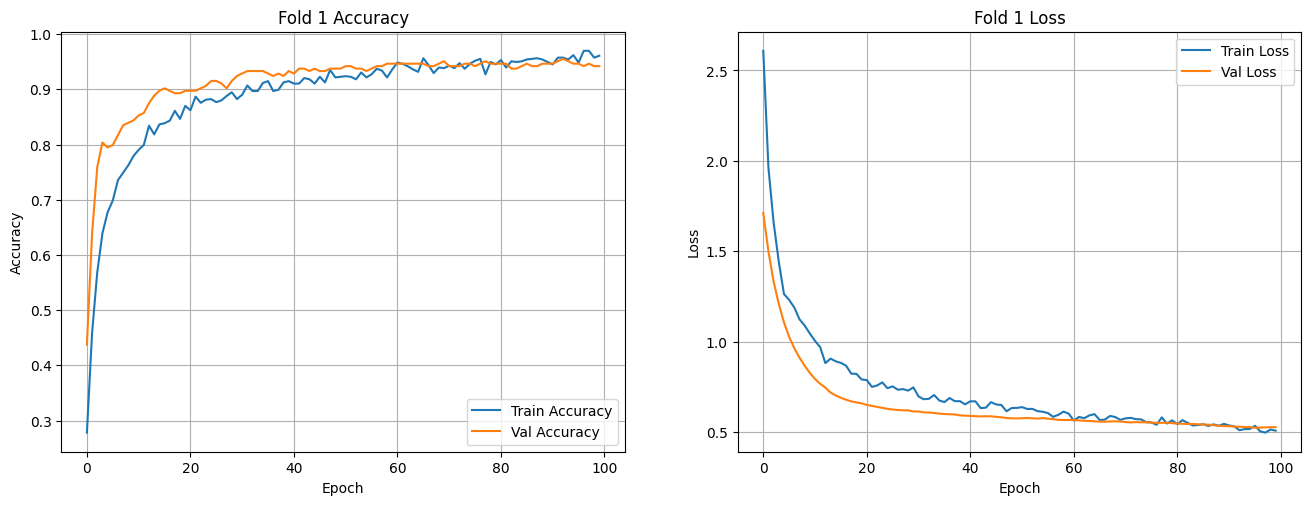

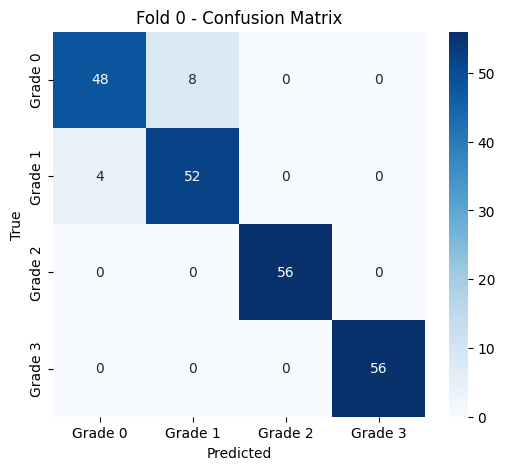

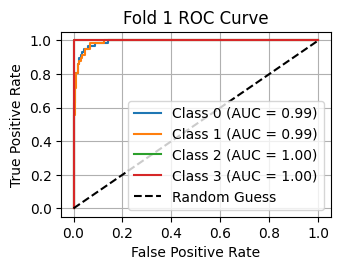


--- Fold 2/5 ---
Epoch 1/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 9s 174ms/step - accuracy: 0.2348 - loss: 2.7558 - val_accuracy: 0.4215 - val_loss: 1.6747 - learning_rate: 3.0000e-05
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.4425 - loss: 1.9222 - val_accuracy: 0.6547 - val_loss: 1.4530 - learning_rate: 3.0000e-05
Epoch 3/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5687 - loss: 1.6166 - val_accuracy: 0.7444 - val_loss: 1.2931 - learning_rate: 3.0000e-05
Epoch 4/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5990 - loss: 1.5147 - val_accuracy: 0.7937 - val_loss: 1.1780 - learning_rate: 3.0000e-05
Epoch 5/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6597 - loss: 1.3850 - val_accuracy: 0.8117 - val_loss: 1.0877 - learning_rate: 3.0000e-05
Epoch 6/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7042 - loss: 1.2306 - val_accuracy: 0.8296 - val_loss: 1.0142 - learning_rate: 3.0000e-05
Epoch 7/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 14m

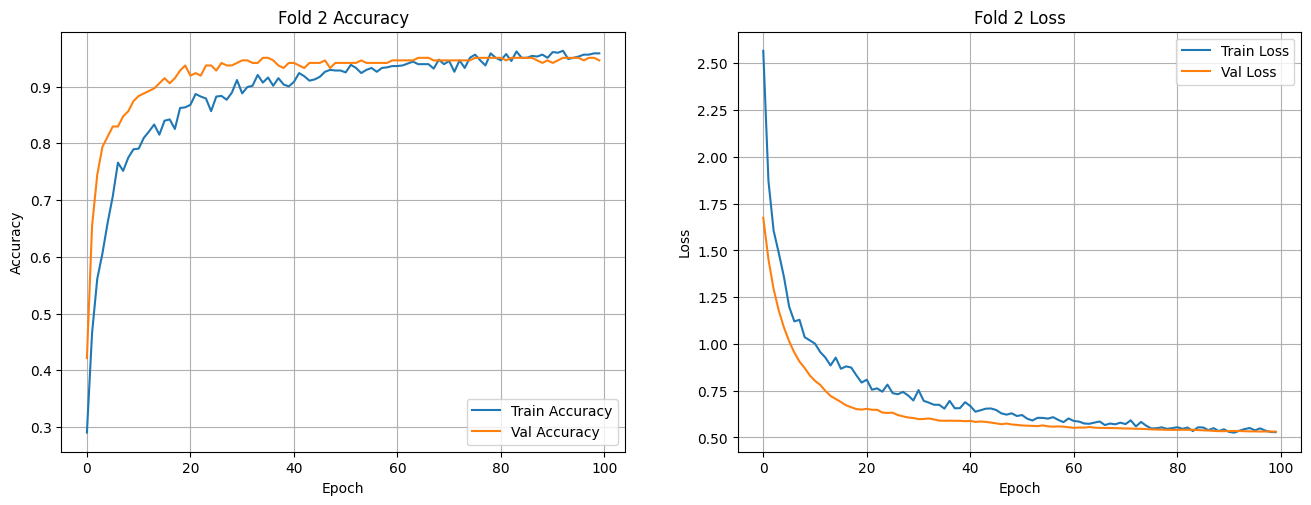

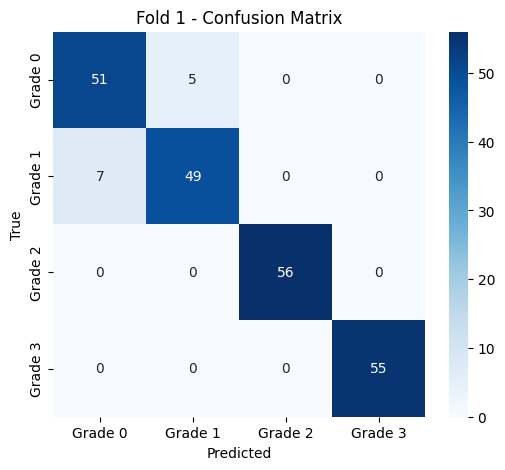

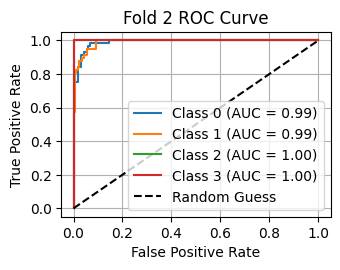


--- Fold 3/5 ---
Epoch 1/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 9s 157ms/step - accuracy: 0.3530 - loss: 2.3104 - val_accuracy: 0.5247 - val_loss: 1.6221 - learning_rate: 3.0000e-05
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4996 - loss: 1.7518 - val_accuracy: 0.6099 - val_loss: 1.4172 - learning_rate: 3.0000e-05
Epoch 3/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5811 - loss: 1.5377 - val_accuracy: 0.6996 - val_loss: 1.2782 - learning_rate: 3.0000e-05
Epoch 4/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6614 - loss: 1.3267 - val_accuracy: 0.7892 - val_loss: 1.1612 - learning_rate: 3.0000e-05
Epoch 5/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6888 - loss: 1.2164 - val_accuracy: 0.8027 - val_loss: 1.0657 - learning_rate: 3.0000e-05
Epoch 6/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7241 - loss: 1.1852 - val_accuracy: 0.8296 - val_loss: 0.9897 - learning_rate: 3.0000e-05
Epoch 7/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 16m

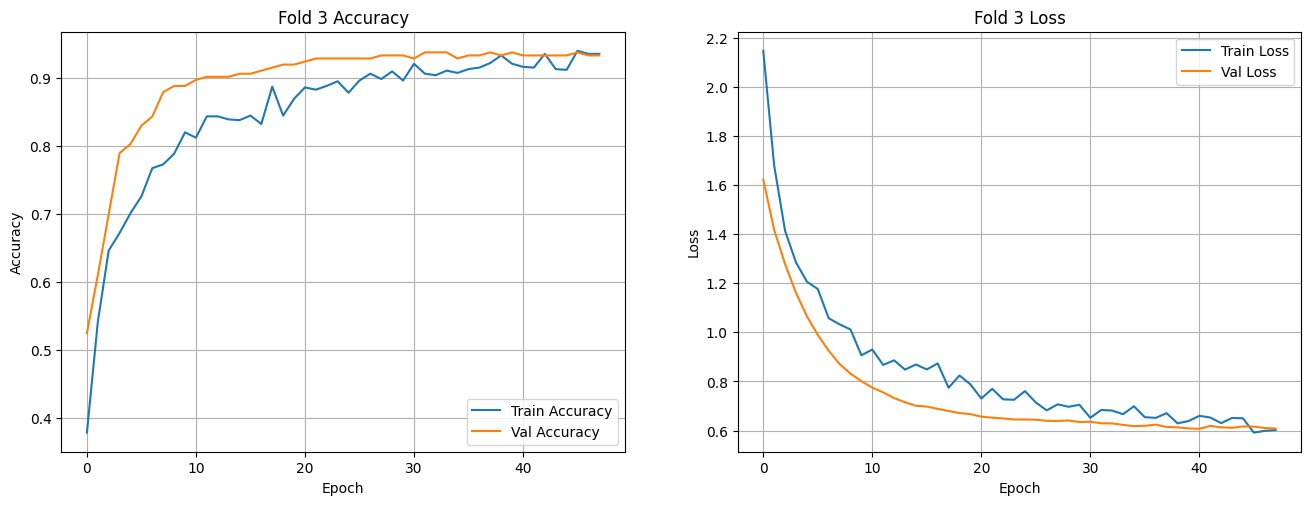

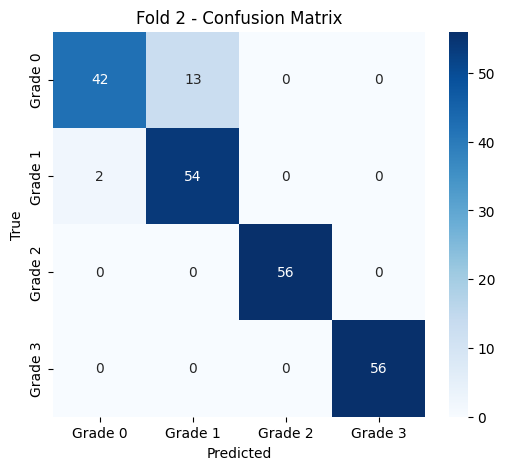

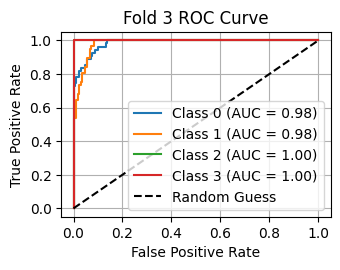


--- Fold 4/5 ---
Epoch 1/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 8s 123ms/step - accuracy: 0.2705 - loss: 2.8067 - val_accuracy: 0.4574 - val_loss: 1.7335 - learning_rate: 3.0000e-05
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.4211 - loss: 2.0717 - val_accuracy: 0.6278 - val_loss: 1.4970 - learning_rate: 3.0000e-05
Epoch 3/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.5478 - loss: 1.6997 - val_accuracy: 0.6592 - val_loss: 1.3342 - learning_rate: 3.0000e-05
Epoch 4/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6234 - loss: 1.4989 - val_accuracy: 0.6682 - val_loss: 1.2268 - learning_rate: 3.0000e-05
Epoch 5/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.6634 - loss: 1.3463 - val_accuracy: 0.7578 - val_loss: 1.1409 - learning_rate: 3.0000e-05
Epoch 6/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7006 - loss: 1.2374 - val_accuracy: 0.7848 - val_loss: 1.0739 - learning_rate: 3.0000e-05
Epoch 7/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 16m

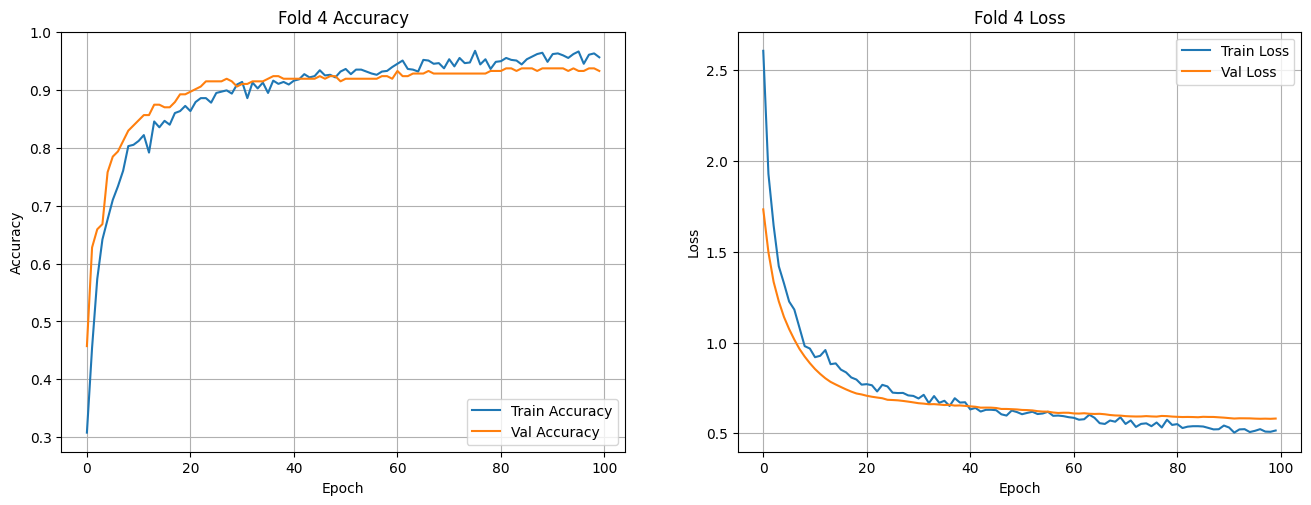

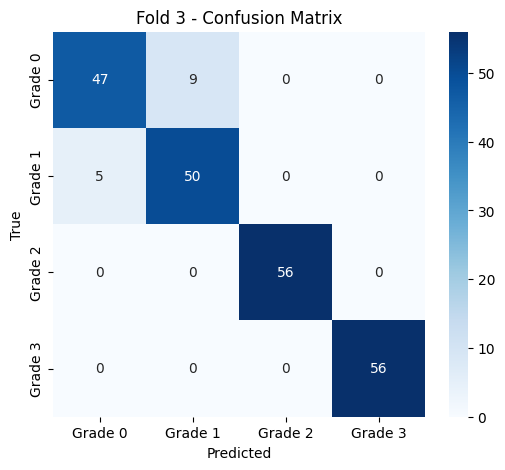

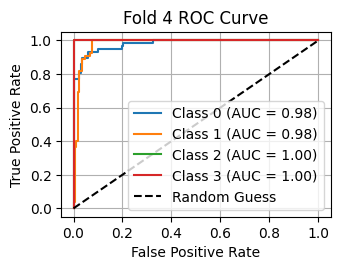


--- Fold 5/5 ---
Epoch 1/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 8s 147ms/step - accuracy: 0.2778 - loss: 2.7236 - val_accuracy: 0.4439 - val_loss: 1.7106 - learning_rate: 3.0000e-05
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.4714 - loss: 1.8567 - val_accuracy: 0.6233 - val_loss: 1.4779 - learning_rate: 3.0000e-05
Epoch 3/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5661 - loss: 1.6140 - val_accuracy: 0.6906 - val_loss: 1.3236 - learning_rate: 3.0000e-05
Epoch 4/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.6417 - loss: 1.3954 - val_accuracy: 0.7354 - val_loss: 1.2104 - learning_rate: 3.0000e-05
Epoch 5/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6674 - loss: 1.3326 - val_accuracy: 0.7444 - val_loss: 1.1260 - learning_rate: 3.0000e-05
Epoch 6/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7278 - loss: 1.1886 - val_accuracy: 0.7623 - val_loss: 1.0622 - learning_rate: 3.0000e-05
Epoch 7/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 18m

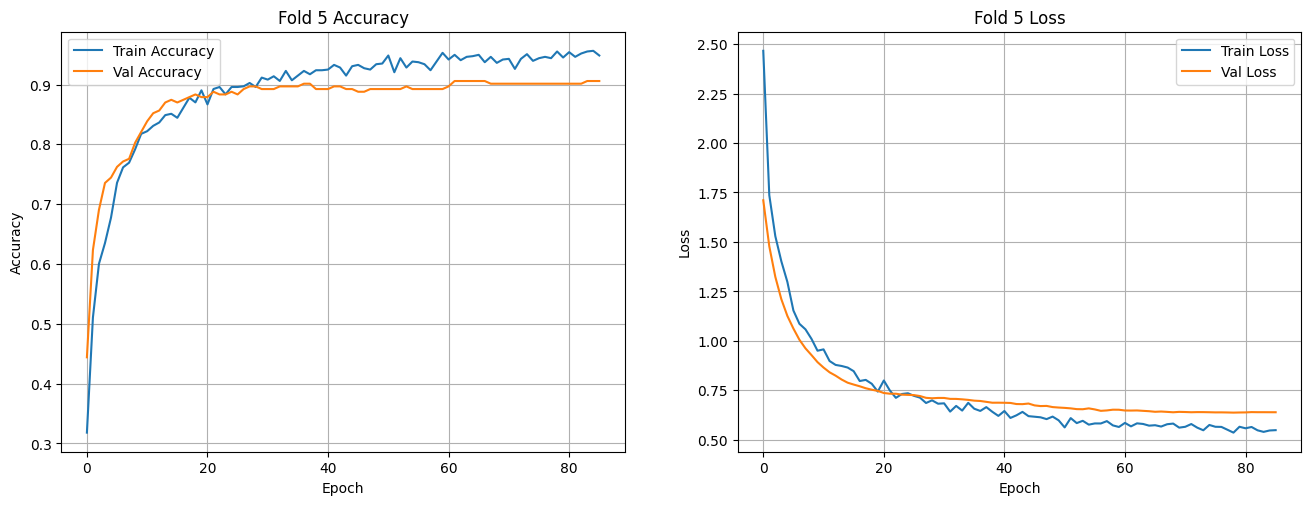

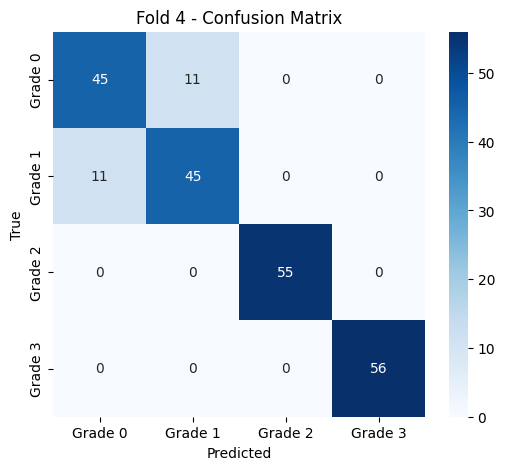

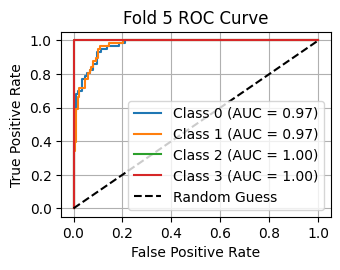

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import layers, Input, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.preprocessing import label_binarize

n_splits = 5

val_accuracies = []
val_losses = []
histories = []
reports = []

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_resampled, y_resampled)):
    print(f"\n--- Fold {fold + 1}/{n_splits} ---")

    X_img_train_fold = X_resampled[train_idx, :image_features.shape[1]].reshape(-1, 7, 7, 2048)
    X_txt_train_fold = X_resampled[train_idx, image_features.shape[1]:]
    y_train_fold = to_categorical(y_resampled[train_idx], num_classes=4)

    X_img_val_fold = X_resampled[val_idx, :image_features.shape[1]].reshape(-1, 7, 7, 2048)
    X_txt_val_fold = X_resampled[val_idx, image_features.shape[1]:]
    y_val_fold = to_categorical(y_resampled[val_idx], num_classes=4)

    class_weights_fold = compute_class_weight(class_weight='balanced', classes=np.unique(y_resampled[train_idx]), y=y_resampled[train_idx])
    class_weights_dict_fold = {i: w for i, w in enumerate(class_weights_fold)}

    image_input = Input(shape=(7, 7, 2048))
    x1 = layers.GlobalAveragePooling2D()(image_input)
    x1 = layers.Dropout(0.3)(x1)

    text_input = Input(shape=(X_txt_train_fold.shape[1],))
    x2 = layers.Dense(64, activation='relu')(text_input)
    x2 = layers.BatchNormalization()(x2)
    x2 = layers.Dropout(0.3)(x2)

    merged = layers.Concatenate()([x1, x2])
    x = layers.Dense(256, activation='relu', kernel_regularizer=l2(0.001))(merged)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    output = layers.Dense(4, activation='softmax')(x)

    model = Model(inputs=[image_input, text_input], outputs=output)

    model.compile(optimizer=Adam(learning_rate=3e-5),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    callbacks = [
        EarlyStopping(patience=7, restore_best_weights=True, monitor='val_loss'),
        ReduceLROnPlateau(patience=4, factor=0.5, min_lr=1e-7, monitor='val_loss'),
        ModelCheckpoint(f'fusion_model_malignancy_fold{fold+1}.keras', save_best_only=True, monitor='val_accuracy')
    ]

    history = model.fit(
        [X_img_train_fold, X_txt_train_fold], y_train_fold,
        validation_data=([X_img_val_fold, X_txt_val_fold], y_val_fold),
        epochs=100,
        batch_size=32,
        class_weight=class_weights_dict_fold,
        callbacks=callbacks,
        verbose=1
    )
    histories.append(history)

    val_loss, val_acc = model.evaluate([X_img_val_fold, X_txt_val_fold], y_val_fold, verbose=0)
    val_accuracies.append(val_acc)
    val_losses.append(val_loss)
    print(f"Fold {fold+1} Validation Accuracy: {val_acc:.4f}")
    print(f"Fold {fold+1} Validation Loss: {val_loss:.4f}")

    y_pred_prob = model.predict([X_img_val_fold, X_txt_val_fold])
    y_pred_labels = np.argmax(y_pred_prob, axis=1)
    y_true_labels = np.argmax(y_val_fold, axis=1)

    from sklearn.metrics import classification_report
    report = classification_report(y_true_labels, y_pred_labels, output_dict=True)
    reports.append(report)
    print(f"Fold {fold+1} Classification Report:")
    print(classification_report(y_true_labels, y_pred_labels))

    plt.figure(figsize=(16, 12))
    plt.subplot(2, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title(f'Fold {fold+1} Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid()
    plt.subplot(2, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'Fold {fold+1} Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid()

    N_CLASSES = 4
    cm = confusion_matrix(y_true_labels, y_pred_labels)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[f'Grade {i}' for i in range(N_CLASSES)],
                yticklabels=[f'Grade {i}' for i in range(N_CLASSES)])
    plt.title(f'Fold {fold} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    y_val_bin = label_binarize(y_true_labels, classes=[0, 1, 2, 3])
    N_CLASSES = 4

    plt.subplot(2, 2, 4)
    fpr = {}
    tpr = {}
    roc_auc = {}

    for i in range(N_CLASSES):
        fpr[i], tpr[i], _ = roc_curve(y_val_bin[:, i], y_pred_prob[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
    plt.title(f'Fold {fold+1} ROC Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [ ]:
import pandas as pd
import numpy as np
import os
from tensorflow.keras.applications import Xception
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tqdm import tqdm
import tensorflow as tf
from sklearn.preprocessing import StandardScaler, LabelEncoder

df = pd.concat([train_df, validation_df], ignore_index=True)
df = df[~df['diagnosis'].isna()]
df['diagnosis'] = df['diagnosis'].astype(int)

labels = to_categorical(df['diagnosis'].values, num_classes=2)

def load_and_preprocess_image(path):
    try:
        img = load_img(path, target_size=(224, 224))
        img_array = img_to_array(img)
        return tf.keras.applications.xception.preprocess_input(img_array)
    except:
        print(f" مشکل در بارگذاری: {path}")
        return None

images = []
valid_indices = []

for i, path in enumerate(tqdm(df['image_path'].values)):
    img = load_and_preprocess_image(path)
    if img is not None:
        images.append(img)
        valid_indices.append(i)

images = np.array(images)
labels = labels[valid_indices]
df = df.iloc[valid_indices].reset_index(drop=True)

textual_features = ['gender', 'clark', 'breslow(mm)', 'ulceration', 'mitotic']
df['gender'] = LabelEncoder().fit_transform(df['gender'])
df[textual_features] = df[textual_features].fillna(0)
X_text = df[textual_features].values

scaler = StandardScaler()
X_text_scaled = scaler.fit_transform(X_text)

base_cnn = Xception(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
image_features = base_cnn.predict(images, verbose=1)
image_features = image_features.reshape(image_features.shape[0], -1)

X_combined = np.hstack([image_features, X_text_scaled])
y_raw = np.argmax(labels, axis=1)

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_combined, y_raw)
y_resampled_cat = to_categorical(y_resampled, num_classes=2)

X_img_resampled = X_resampled[:, :image_features.shape[1]].reshape(-1, 7, 7, 2048)
X_text_resampled = X_resampled[:, image_features.shape[1]:]

X_img_train, X_img_val, X_txt_train, X_txt_val, y_train, y_val = train_test_split(
    X_img_resampled, X_text_resampled, y_resampled_cat, test_size=0.2, stratify=y_resampled, random_state=42
)

class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_resampled), y=y_resampled)
class_weights_dict = {i: w for i, w in enumerate(class_weights)}

image_input = Input(shape=(7, 7, 2048))
x1 = layers.GlobalAveragePooling2D()(image_input)
x1 = layers.Dropout(0.3)(x1)

text_input = Input(shape=(X_txt_train.shape[1],))
x2 = layers.Dense(64, activation='relu')(text_input)
x2 = layers.BatchNormalization()(x2)
x2 = layers.Dropout(0.3)(x2)

merged = layers.Concatenate()([x1, x2])
x = layers.Dense(256, activation='relu', kernel_regularizer=l2(0.001))(merged)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)
output = layers.Dense(2, activation='softmax')(x)

fusion_model = Model(inputs=[image_input, text_input], outputs=output)

fusion_model.compile(optimizer=Adam(learning_rate=3e-5),
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

callbacks = [
    EarlyStopping(patience=7, restore_best_weights=True, monitor='val_loss'),
    ReduceLROnPlateau(patience=4, factor=0.5, min_lr=1e-7, monitor='val_loss'),
    ModelCheckpoint('fusion_model_diagnosis.keras', save_best_only=True, monitor='val_accuracy')
]

history = fusion_model.fit(
    [X_img_train, X_txt_train], y_train,
    validation_data=([X_img_val, X_txt_val], y_val),
    epochs=100,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=callbacks,
    verbose=1
)

val_loss, val_acc = fusion_model.evaluate([X_img_val, X_txt_val], y_val, verbose=0)
print(f"\n Validation Accuracy: {val_acc:.4f}")
print(f" Validation Loss: {val_loss:.4f}")

y_pred = fusion_model.predict([X_img_val, X_txt_val])
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_val, axis=1)

print("\n Classification Report:\n")
print(classification_report(y_true_labels, y_pred_labels))

 29%|██▊       | 174/608 [00:01<00:04, 94.18it/s]

❌ مشکل در بارگذاری: /content/drive/MyDrive/train/malignant/p1 .jpg


100%|██████████| 608/608 [02:37<00:00,  3.87it/s]


19/19 ━━━━━━━━━━━━━━━━━━━━ 12s 516ms/step
Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 304ms/step - accuracy: 0.5147 - loss: 1.4751 - val_accuracy: 0.6894 - val_loss: 1.0560 - learning_rate: 3.0000e-05
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6468 - loss: 1.3257 - val_accuracy: 0.7273 - val_loss: 0.9950 - learning_rate: 3.0000e-05
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6797 - loss: 1.2228 - val_accuracy: 0.7576 - val_loss: 0.9537 - learning_rate: 3.0000e-05
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7233 - loss: 1.0763 - val_accuracy: 0.7803 - val_loss: 0.9224 - learning_rate: 3.0000e-05
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7519 - loss: 1.0449 - val_accuracy: 0.7803 - val_loss: 0.9025 - learning_rate: 3.0000e-05
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7674 - loss: 1.0518 - val_accuracy: 0.7955 - val_loss: 0.8861 - learning_rate: 3.0000e-05
Epoch 7/100
17/17 ━━━

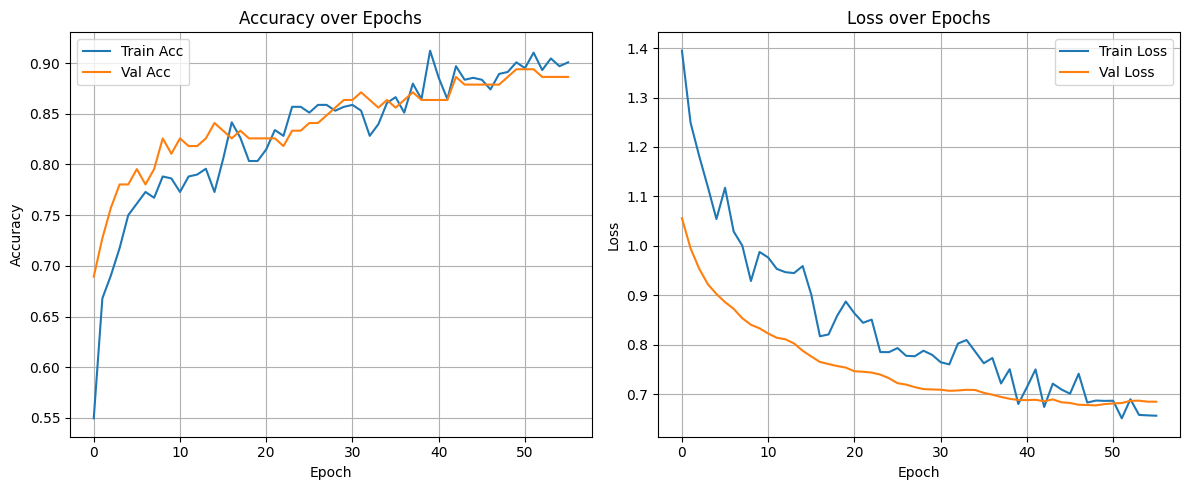

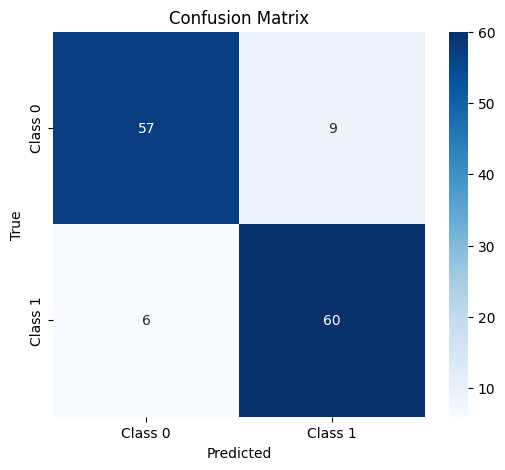

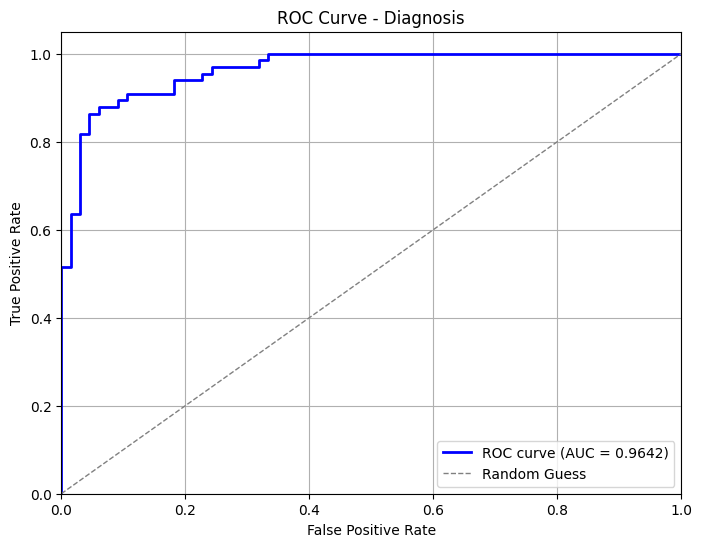

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc
import seaborn as sns

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

conf_mat = confusion_matrix(y_true_labels, y_pred_labels)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

y_true = y_val[:, 1]
y_scores = y_pred[:, 1]

fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Guess')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Diagnosis')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

 28%|██▊       | 168/608 [00:02<00:05, 86.01it/s]

❌ مشکل در بارگذاری: /content/drive/MyDrive/train/malignant/p1 .jpg


100%|██████████| 608/608 [00:07<00:00, 84.18it/s]


19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 265ms/step

--- Fold 1 ---
Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 256ms/step - accuracy: 0.4720 - loss: 1.6813 - val_accuracy: 0.6475 - val_loss: 1.0990 - learning_rate: 3.0000e-05
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5861 - loss: 1.3666 - val_accuracy: 0.7213 - val_loss: 1.0422 - learning_rate: 3.0000e-05
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6595 - loss: 1.2194 - val_accuracy: 0.7131 - val_loss: 0.9990 - learning_rate: 3.0000e-05
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7138 - loss: 1.1216 - val_accuracy: 0.7295 - val_loss: 0.9628 - learning_rate: 3.0000e-05
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6932 - loss: 1.1623 - val_accuracy: 0.7623 - val_loss: 0.9346 - learning_rate: 3.0000e-05
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7591 - loss: 1.0310 - val_accuracy: 0.7787 - val_loss: 0.9151 - learning_rate: 3.0000e-05
Epoch 

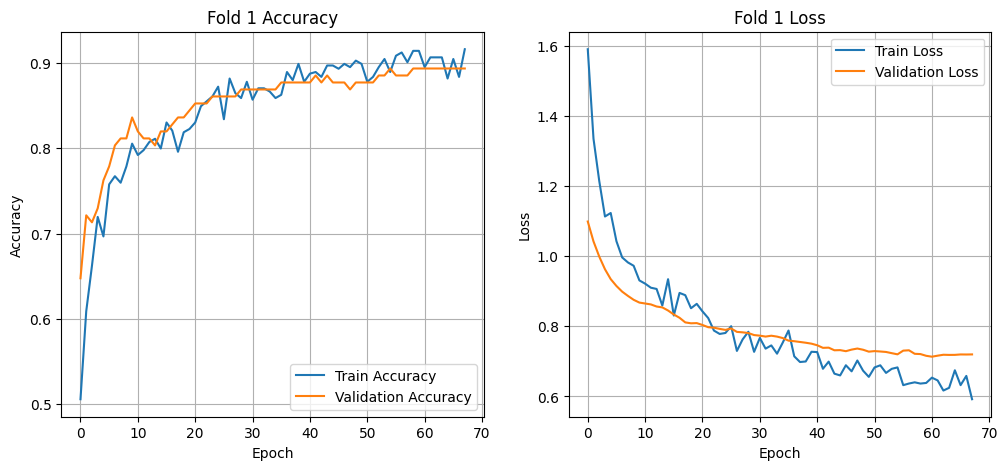

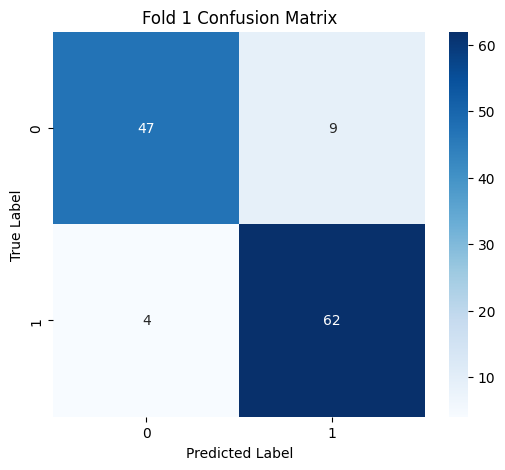

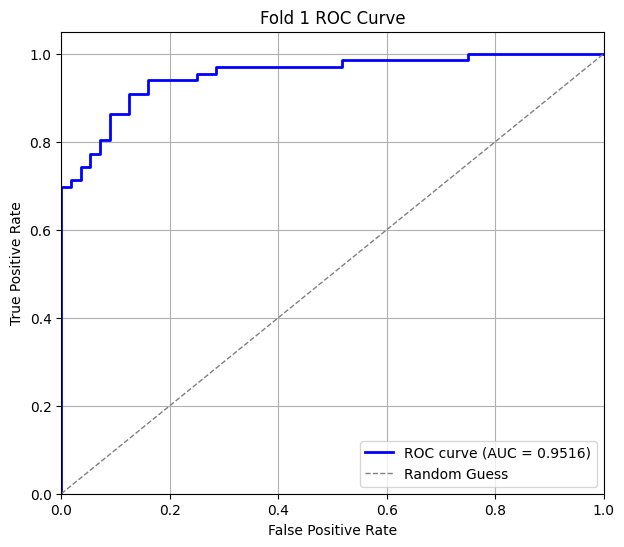


--- Fold 2 ---
Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 7s 202ms/step - accuracy: 0.4814 - loss: 1.6398 - val_accuracy: 0.6475 - val_loss: 1.0873 - learning_rate: 3.0000e-05
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6242 - loss: 1.3430 - val_accuracy: 0.7377 - val_loss: 1.0105 - learning_rate: 3.0000e-05
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6865 - loss: 1.1793 - val_accuracy: 0.7869 - val_loss: 0.9693 - learning_rate: 3.0000e-05
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6802 - loss: 1.1518 - val_accuracy: 0.7869 - val_loss: 0.9438 - learning_rate: 3.0000e-05
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7265 - loss: 1.1106 - val_accuracy: 0.7869 - val_loss: 0.9254 - learning_rate: 3.0000e-05
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7552 - loss: 0.9784 - val_accuracy: 0.8033 - val_loss: 0.9119 - learning_rate: 3.0000e-05
Epoch 7/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/

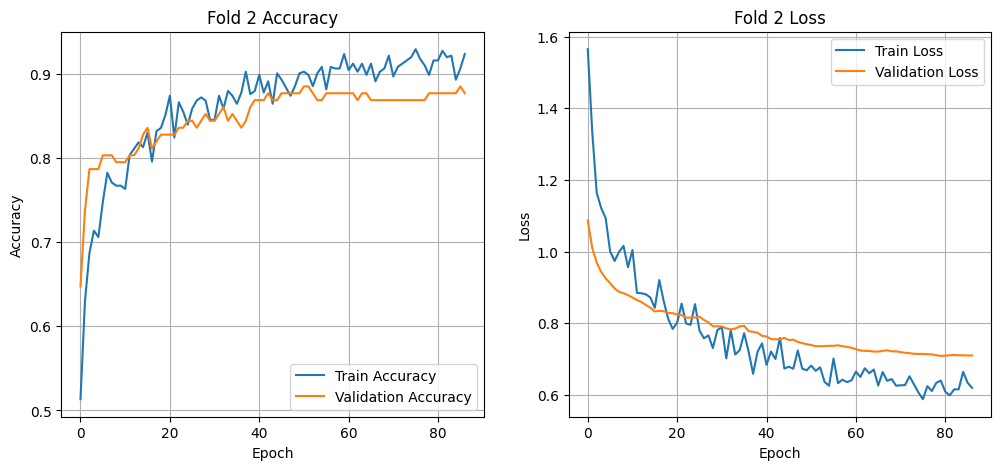

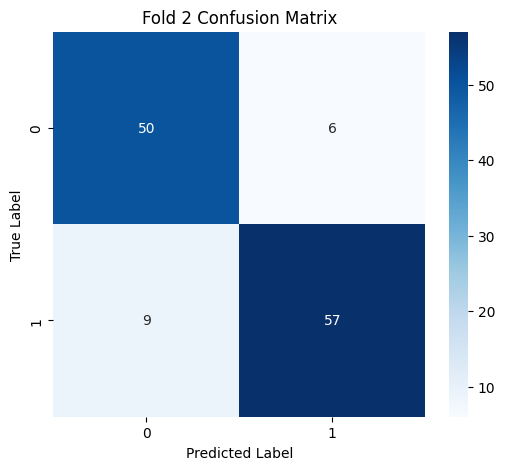

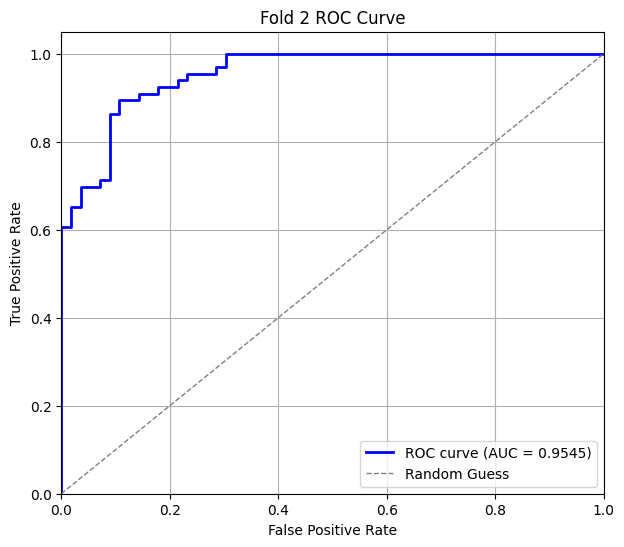


--- Fold 3 ---
Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 279ms/step - accuracy: 0.5631 - loss: 1.4122 - val_accuracy: 0.4959 - val_loss: 1.1969 - learning_rate: 3.0000e-05
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.6361 - loss: 1.3984 - val_accuracy: 0.5868 - val_loss: 1.1386 - learning_rate: 3.0000e-05
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7000 - loss: 1.0640 - val_accuracy: 0.6446 - val_loss: 1.0813 - learning_rate: 3.0000e-05
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7231 - loss: 1.1040 - val_accuracy: 0.6860 - val_loss: 1.0365 - learning_rate: 3.0000e-05
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7471 - loss: 1.0316 - val_accuracy: 0.7190 - val_loss: 0.9973 - learning_rate: 3.0000e-05
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7664 - loss: 1.0401 - val_accuracy: 0.7686 - val_loss: 0.9625 - learning_rate: 3.0000e-05
Epoch 7/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/

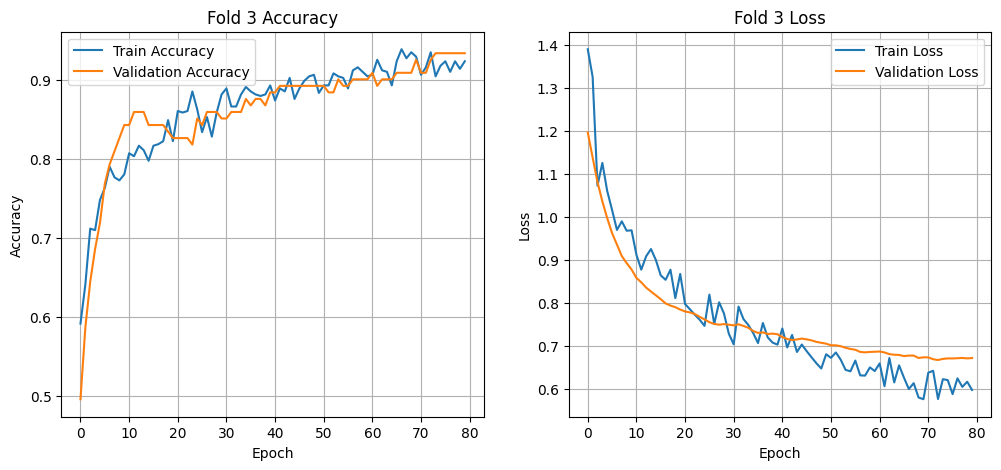

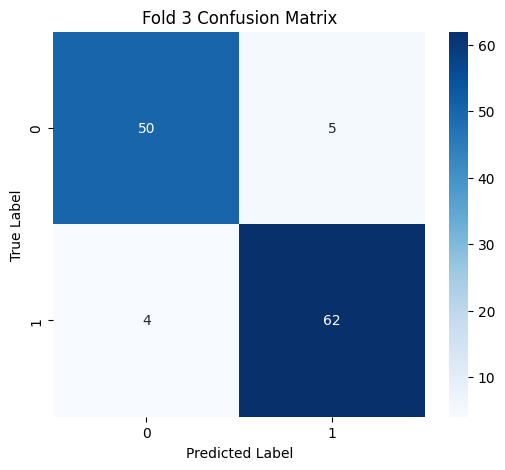

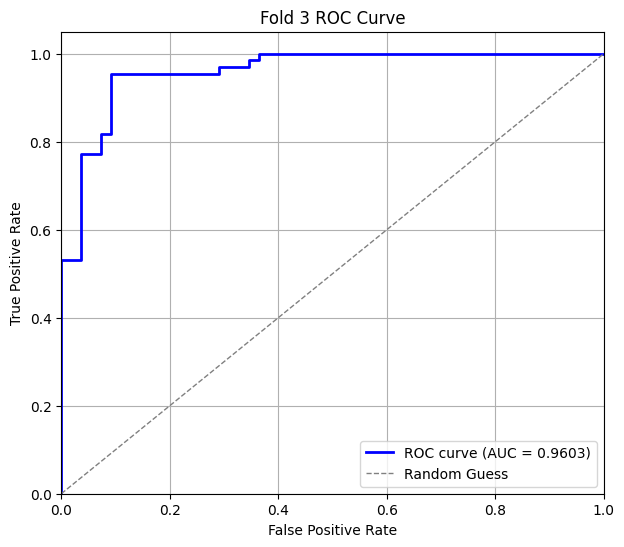


--- Fold 4 ---
Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 219ms/step - accuracy: 0.4536 - loss: 1.7948 - val_accuracy: 0.5702 - val_loss: 1.1484 - learning_rate: 3.0000e-05
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.6817 - loss: 1.2223 - val_accuracy: 0.6281 - val_loss: 1.0812 - learning_rate: 3.0000e-05
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6740 - loss: 1.1897 - val_accuracy: 0.6446 - val_loss: 1.0417 - learning_rate: 3.0000e-05
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7028 - loss: 1.1534 - val_accuracy: 0.6942 - val_loss: 1.0190 - learning_rate: 3.0000e-05
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7167 - loss: 1.0951 - val_accuracy: 0.7190 - val_loss: 0.9998 - learning_rate: 3.0000e-05
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7804 - loss: 1.0189 - val_accuracy: 0.7273 - val_loss: 0.9842 - learning_rate: 3.0000e-05
Epoch 7/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/

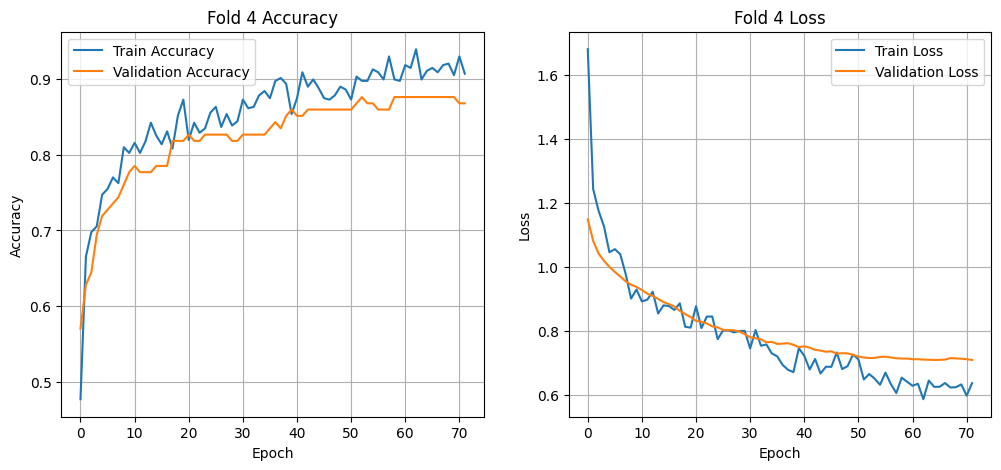

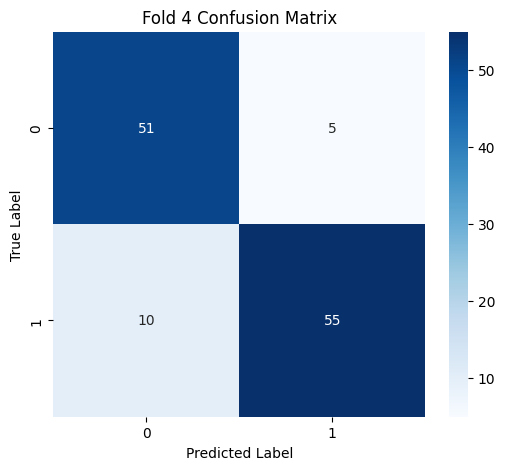

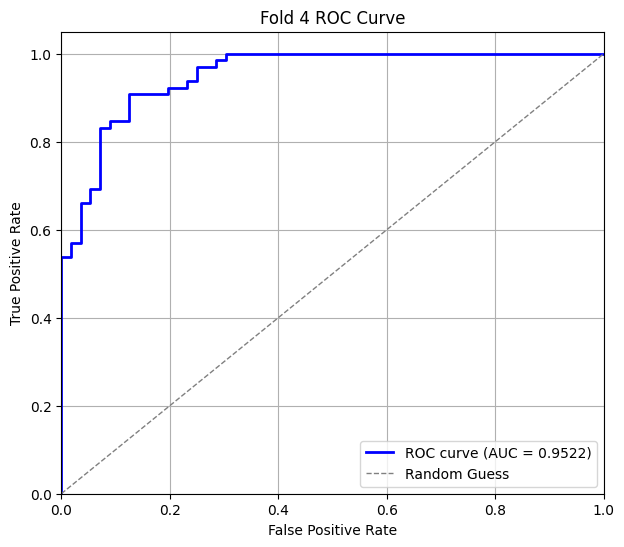


--- Fold 5 ---
Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 185ms/step - accuracy: 0.6003 - loss: 1.3966 - val_accuracy: 0.7190 - val_loss: 1.0331 - learning_rate: 3.0000e-05
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6690 - loss: 1.1101 - val_accuracy: 0.7438 - val_loss: 0.9866 - learning_rate: 3.0000e-05
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7578 - loss: 1.0516 - val_accuracy: 0.7438 - val_loss: 0.9543 - learning_rate: 3.0000e-05
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7360 - loss: 1.0257 - val_accuracy: 0.7686 - val_loss: 0.9310 - learning_rate: 3.0000e-05
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7531 - loss: 1.0140 - val_accuracy: 0.7934 - val_loss: 0.9073 - learning_rate: 3.0000e-05
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7612 - loss: 0.9822 - val_accuracy: 0.8099 - val_loss: 0.8911 - learning_rate: 3.0000e-05
Epoch 7/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/

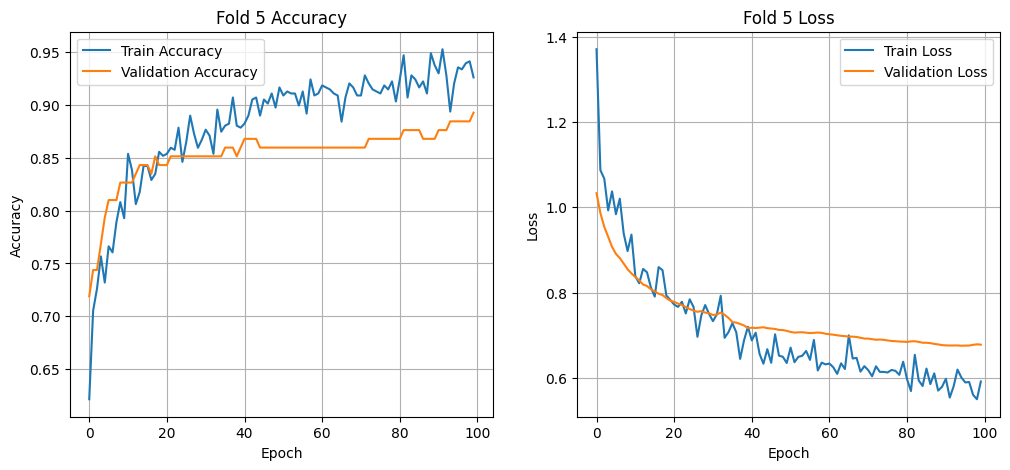

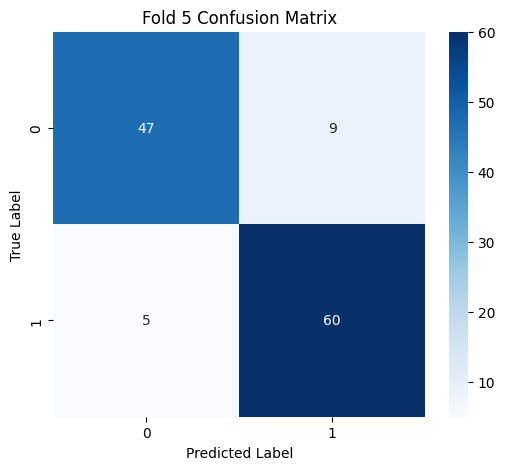

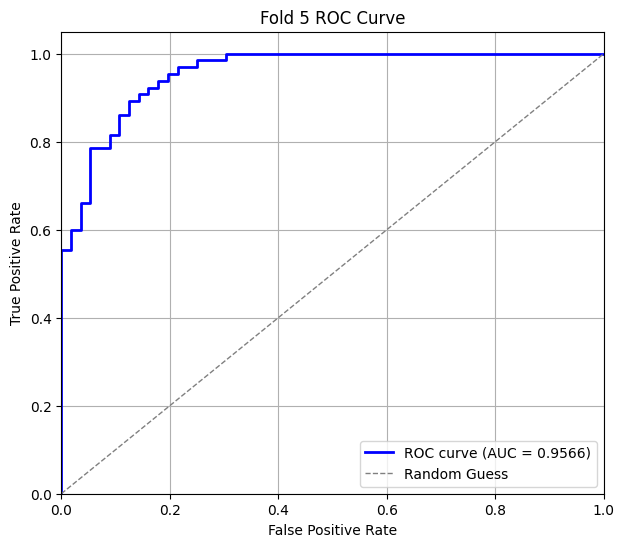

In [ ]:
import pandas as pd
import numpy as np
from tensorflow.keras.applications import Xception
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from imblearn.over_sampling import SMOTE
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tqdm import tqdm
import tensorflow as tf
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.concat([train_df, validation_df], ignore_index=True)
df = df[~df['diagnosis'].isna()]
df['diagnosis'] = df['diagnosis'].astype(int)

labels = to_categorical(df['diagnosis'].values, num_classes=2)

def load_and_preprocess_image(path):
    try:
        img = load_img(path, target_size=(224, 224))
        img_array = img_to_array(img)
        return tf.keras.applications.xception.preprocess_input(img_array)
    except:
        print(f" مشکل در بارگذاری: {path}")
        return None

images = []
valid_indices = []

for i, path in enumerate(tqdm(df['image_path'].values)):
    img = load_and_preprocess_image(path)
    if img is not None:
        images.append(img)
        valid_indices.append(i)

images = np.array(images)
labels = labels[valid_indices]
df = df.iloc[valid_indices].reset_index(drop=True)

textual_features = ['gender', 'clark', 'breslow(mm)', 'ulceration', 'mitotic']
df['gender'] = LabelEncoder().fit_transform(df['gender'])
df[textual_features] = df[textual_features].fillna(0)
X_text = df[textual_features].values
scaler = StandardScaler()
X_text_scaled = scaler.fit_transform(X_text)

base_cnn = Xception(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
image_features = base_cnn.predict(images, verbose=1)
image_features = image_features.reshape(image_features.shape[0], -1)

X_combined = np.hstack([image_features, X_text_scaled])
y_raw = np.argmax(labels, axis=1)

# --- KFold ---
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_no = 1

for train_index, val_index in kf.split(X_combined, y_raw):
    print(f"\n--- Fold {fold_no} ---")

    X_train_raw, X_val_raw = X_combined[train_index], X_combined[val_index]
    y_train_raw, y_val_raw = y_raw[train_index], y_raw[val_index]

    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train_raw, y_train_raw)
    y_train_cat = to_categorical(y_train_res, num_classes=2)
    y_val_cat = to_categorical(y_val_raw, num_classes=2)

    X_img_train = X_train_res[:, :image_features.shape[1]].reshape(-1, 7, 7, 2048)
    X_text_train = X_train_res[:, image_features.shape[1]:]

    X_img_val = X_val_raw[:, :image_features.shape[1]].reshape(-1, 7, 7, 2048)
    X_text_val = X_val_raw[:, image_features.shape[1]:]

    class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train_res), y=y_train_res)
    class_weights_dict = {i: w for i, w in enumerate(class_weights)}

    image_input = Input(shape=(7, 7, 2048))
    x1 = layers.GlobalAveragePooling2D()(image_input)
    x1 = layers.Dropout(0.3)(x1)

    text_input = Input(shape=(X_text_train.shape[1],))
    x2 = layers.Dense(64, activation='relu')(text_input)
    x2 = layers.BatchNormalization()(x2)
    x2 = layers.Dropout(0.3)(x2)

    merged = layers.Concatenate()([x1, x2])
    x = layers.Dense(256, activation='relu', kernel_regularizer=l2(0.001))(merged)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    output = layers.Dense(2, activation='softmax')(x)

    model = Model(inputs=[image_input, text_input], outputs=output)
    model.compile(optimizer=Adam(learning_rate=3e-5),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    callbacks = [
        EarlyStopping(patience=7, restore_best_weights=True, monitor='val_loss'),
        ReduceLROnPlateau(patience=4, factor=0.5, min_lr=1e-7, monitor='val_loss')
    ]

    history = model.fit(
        [X_img_train, X_text_train], y_train_cat,
        validation_data=([X_img_val, X_text_val], y_val_cat),
        epochs=100,
        batch_size=32,
        class_weight=class_weights_dict,
        callbacks=callbacks,
        verbose=1
    )
    val_loss, val_acc = model.evaluate([X_img_val, X_text_val], y_val_cat, verbose=0)
    print(f"\n Fold {fold_no} Validation Accuracy: {val_acc:.4f}")
    print(f" Fold {fold_no} Validation Loss: {val_loss:.4f}")

    y_pred = model.predict([X_img_val, X_text_val])
    y_pred_labels = np.argmax(y_pred, axis=1)
    y_true_labels = np.argmax(y_val_cat, axis=1)

    print(f"\n📊 Fold {fold_no} Classification Report:\n")
    print(classification_report(y_true_labels, y_pred_labels))

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'Fold {fold_no} Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'Fold {fold_no} Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

    cm = confusion_matrix(y_true_labels, y_pred_labels)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Fold {fold_no} Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    fpr, tpr, _ = roc_curve(y_val_cat[:,1], y_pred[:,1])
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(7,6))
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Guess')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Fold {fold_no} ROC Curve')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

    fold_no += 1

In [ ]:
####### fusion ######

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from tensorflow.keras.applications import Xception
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import tensorflow as tf
from tqdm import tqdm
from tensorflow.keras.regularizers import l2

df = pd.read_excel('/content/train_with_malignancy_grade.xlsx')

df = df[~df['malignancy_grade'].isna()]

df['diagnosis'] = df['diagnosis'].astype(int)
df['malignancy_grade'] = df['malignancy_grade'].astype(int)

features = ['breslow(mm)', 'clark', 'ulceration', 'mitotic']
df[features] = df[features].fillna(0)
X_text = df[features].values
scaler = StandardScaler()
X_text_scaled = scaler.fit_transform(X_text)

y_diagnosis = df['diagnosis'].values
y_grade = to_categorical(df['malignancy_grade'].values, num_classes=4)

def preprocess_image(path):
    try:
        img = load_img(path.strip(), target_size=(224, 224))
        arr = img_to_array(img)
        return tf.keras.applications.xception.preprocess_input(arr)
    except Exception as e:
        print(f" Error loading: {path} --> {e}")
        return None

X_img, valid_indices = [], []
for i, p in enumerate(tqdm(df['image_path'])):
    img = preprocess_image(p)
    if img is not None:
        X_img.append(img)
        valid_indices.append(i)

X_img = np.array(X_img)
X_text_scaled = X_text_scaled[valid_indices]
y_diagnosis = y_diagnosis[valid_indices]
y_grade = y_grade[valid_indices]

xcep = Xception(weights='imagenet', include_top=False, input_shape=(224,224,3))
X_img_feat = xcep.predict(X_img, verbose=1)
X_img_feat = X_img_feat.reshape(X_img_feat.shape[0], -1)

X_fused = np.hstack([X_img_feat, X_text_scaled])

smote = SMOTE(random_state=42)
X_resampled, y_diagnosis_resampled = smote.fit_resample(X_fused, y_diagnosis)

X_img_res = X_resampled[:, :X_img_feat.shape[1]].reshape(-1, 7, 7, 2048)
X_text_res = X_resampled[:, X_img_feat.shape[1]:]

malignant_mask_resampled = y_diagnosis_resampled == 1
X_img_malignant = X_img_res[malignant_mask_resampled]
X_text_malignant = X_text_res[malignant_mask_resampled]

y_grade_valid = y_grade
valid_diagnosis = y_diagnosis

malignant_mask_valid = valid_diagnosis == 1
y_grade_malignant = y_grade_valid[malignant_mask_valid]

y_grade_res = y_grade_malignant[:len(X_img_malignant)]

X_img_train, X_img_val, X_txt_train, X_txt_val, y_diag_train, y_diag_val = train_test_split(
    X_img_res, X_text_res, y_diagnosis_resampled, test_size=0.2, random_state=42, stratify=y_diagnosis_resampled
)

X_img_grade_train, X_img_grade_val, X_txt_grade_train, X_txt_grade_val, y_grade_train, y_grade_val = train_test_split(
    X_img_malignant, X_text_malignant, y_grade_res, test_size=0.2, random_state=42
)

img_in = Input(shape=(7, 7, 2048))
x1 = layers.GlobalAveragePooling2D()(img_in)
x1 = layers.Dropout(0.3)(x1)

txt_in = Input(shape=(X_text_res.shape[1],))
x2 = layers.Dense(64, activation='relu')(txt_in)
x2 = layers.BatchNormalization()(x2)
x2 = layers.Dropout(0.3)(x2)

concat = layers.Concatenate()([x1, x2])
x = layers.Dense(256, activation='relu', kernel_regularizer=l2(0.001))(concat)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)

out_diagnosis = layers.Dense(1, activation='sigmoid', name='diagnosis')(x)
out_grade = layers.Dense(4, activation='softmax', name='malignancy_grade')(x)

model = Model(inputs=[img_in, txt_in], outputs=[out_diagnosis, out_grade])

model.compile(
    optimizer=Adam(3e-5),
    loss={'diagnosis': 'binary_crossentropy', 'malignancy_grade': 'categorical_crossentropy'},
    loss_weights={'diagnosis': 1.0, 'malignancy_grade': 1.0},
    metrics={'diagnosis': 'accuracy', 'malignancy_grade': 'accuracy'}
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=7, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=4, factor=0.5),
    tf.keras.callbacks.ModelCheckpoint('fusion_model_dual_output.keras', save_best_only=True)
]


history = model.fit(
    [X_img_train, X_txt_train],
    {'diagnosis': y_diag_train, 'malignancy_grade': np.zeros((len(y_diag_train), 4))},
    validation_data=([X_img_val, X_txt_val], {'diagnosis': y_diag_val, 'malignancy_grade': np.zeros((len(y_diag_val), 4))}),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

 34%|███▍      | 164/478 [00:02<00:04, 72.72it/s]

❌ Error loading: /content/drive/MyDrive/train/malignant/p1 .jpg --> [Errno 2] No such file or directory: '/content/drive/MyDrive/train/malignant/p1 .jpg'


100%|██████████| 478/478 [00:07<00:00, 67.80it/s]


15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 302ms/step
Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 143ms/step - diagnosis_accuracy: 0.4612 - diagnosis_loss: 0.9742 - loss: 1.4308 - malignancy_grade_accuracy: 0.2442 - malignancy_grade_loss: 0.0000e+00 - val_diagnosis_accuracy: 0.5288 - val_diagnosis_loss: 0.7078 - val_loss: 1.1447 - val_malignancy_grade_accuracy: 0.0096 - val_malignancy_grade_loss: 0.0000e+00 - learning_rate: 3.0000e-05
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - diagnosis_accuracy: 0.6237 - diagnosis_loss: 0.7477 - loss: 1.2041 - malignancy_grade_accuracy: 0.2740 - malignancy_grade_loss: 0.0000e+00 - val_diagnosis_accuracy: 0.5865 - val_diagnosis_loss: 0.6874 - val_loss: 1.1154 - val_malignancy_grade_accuracy: 0.0096 - val_malignancy_grade_loss: 0.0000e+00 - learning_rate: 3.0000e-05
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - diagnosis_accuracy: 0.6444 - diagnosis_loss: 0.6936 - loss: 1.1499 - malignancy_grade_accuracy: 0.2241 - malignancy_grade_loss: 0.0000e+00 -

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from tensorflow.keras.applications import Xception
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import tensorflow as tf
from tqdm import tqdm
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2

train_df = pd.read_excel('/content/train_with_malignancy_grade.xlsx')
val_df = pd.read_excel('/content/validation_with_malignancy_grade.xlsx')

def preprocess_df(df, scaler=None, fit_scaler=False):
    df = df[~df['malignancy_grade'].isna()]
    df['diagnosis'] = df['diagnosis'].astype(int)
    df['malignancy_grade'] = df['malignancy_grade'].astype(int)

    features = ['breslow(mm)', 'clark', 'ulceration', 'mitotic']
    df[features] = df[features].fillna(0)
    X_text = df[features].values

    if scaler is None:
        scaler = StandardScaler()
    if fit_scaler:
        X_text_scaled = scaler.fit_transform(X_text)
    else:
        X_text_scaled = scaler.transform(X_text)

    y_diagnosis = df['diagnosis'].values
    y_grade = to_categorical(df['malignancy_grade'].values, num_classes=4)

    def preprocess_image(path):
        try:
            img = load_img(path.strip(), target_size=(224, 224))
            arr = img_to_array(img)
            return tf.keras.applications.xception.preprocess_input(arr)
        except Exception as e:
            print(f" Error loading: {path} --> {e}")
            return None

    X_img, valid_indices = [], []
    for i, p in enumerate(tqdm(df['image_path'])):
        img = preprocess_image(p)
        if img is not None:
            X_img.append(img)
            valid_indices.append(i)

    X_img = np.array(X_img)
    X_text_scaled = X_text_scaled[valid_indices]
    y_diagnosis = y_diagnosis[valid_indices]
    y_grade = y_grade[valid_indices]

    return X_img, X_text_scaled, y_diagnosis, y_grade, scaler

X_img_train, X_text_train, y_diag_train, y_grade_train, scaler = preprocess_df(train_df, fit_scaler=True)
X_img_val, X_text_val, y_diag_val, y_grade_val, _ = preprocess_df(val_df, scaler=scaler, fit_scaler=False)

xcep = Xception(weights='imagenet', include_top=False, input_shape=(224,224,3))
X_img_feat_train = xcep.predict(X_img_train, verbose=1)
X_img_feat_val = xcep.predict(X_img_val, verbose=1)

X_img_feat_train = X_img_feat_train.reshape(X_img_feat_train.shape[0], -1)
X_img_feat_val = X_img_feat_val.reshape(X_img_feat_val.shape[0], -1)

X_fused_train = np.hstack([X_img_feat_train, X_text_train])
X_fused_val = np.hstack([X_img_feat_val, X_text_val])

smote = SMOTE(random_state=42)
X_resampled_train, y_diag_resampled_train = smote.fit_resample(X_fused_train, y_diag_train)

img_feat_dim = X_img_feat_train.shape[1]
X_img_res_train = X_resampled_train[:, :img_feat_dim].reshape(-1, 7, 7, 2048)
X_text_res_train = X_resampled_train[:, img_feat_dim:]

malignant_mask_train = y_diag_resampled_train == 1
X_img_malignant_train = X_img_res_train[malignant_mask_train]
X_text_malignant_train = X_text_res_train[malignant_mask_train]

malignant_mask_orig_train = y_diag_train == 1
y_grade_malignant_train = y_grade_train[malignant_mask_orig_train]
y_grade_res_train = y_grade_malignant_train[:len(X_img_malignant_train)]

malignant_mask_val = y_diag_val == 1
X_img_malignant_val = X_img_feat_val[malignant_mask_val].reshape(-1,7,7,2048)
X_text_malignant_val = X_text_val[malignant_mask_val]
y_grade_malignant_val = y_grade_val[malignant_mask_val]

img_in = Input(shape=(7, 7, 2048), name='image_input')
x1 = layers.GlobalAveragePooling2D()(img_in)
x1 = layers.Dropout(0.3)(x1)

txt_in = Input(shape=(X_text_res_train.shape[1],), name='text_input')
x2 = layers.Dense(64, activation='relu')(txt_in)
x2 = layers.BatchNormalization()(x2)
x2 = layers.Dropout(0.3)(x2)

concat = layers.Concatenate()([x1, x2])
x = layers.Dense(256, activation='relu', kernel_regularizer=l2(0.001))(concat)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)

out_diagnosis = layers.Dense(1, activation='sigmoid', name='diagnosis')(x)
out_grade = layers.Dense(4, activation='softmax', name='malignancy_grade')(x)

model = Model(inputs=[img_in, txt_in], outputs=[out_diagnosis, out_grade])

model.compile(
    optimizer=Adam(3e-5),
    loss={
        'diagnosis': 'binary_crossentropy',
        'malignancy_grade': 'categorical_crossentropy'
    },
    loss_weights={
        'diagnosis': 1.0,
        'malignancy_grade': 1.0
    },
    metrics={
        'diagnosis': 'accuracy',
        'malignancy_grade': 'accuracy'
    }
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=7, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=4, factor=0.5),
    tf.keras.callbacks.ModelCheckpoint('fusion_model_dual_output.keras', save_best_only=True)
]

y_grade_train_full = np.zeros((len(y_diag_resampled_train), 4))
y_grade_train_full[malignant_mask_train] = y_grade_res_train

y_grade_val_full = np.zeros((len(y_diag_val), 4))
y_grade_val_full[malignant_mask_val] = y_grade_malignant_val

history = model.fit(
    [X_img_res_train, X_text_res_train],
    {'diagnosis': y_diag_resampled_train, 'malignancy_grade': y_grade_train_full},
    validation_data=(
        [X_img_feat_val.reshape(-1,7,7,2048), X_text_val],
        {'diagnosis': y_diag_val, 'malignancy_grade': y_grade_val_full}
    ),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

 35%|███▌      | 168/478 [00:02<00:05, 60.81it/s]

❌ Error loading: /content/drive/MyDrive/train/malignant/p1 .jpg --> [Errno 2] No such file or directory: '/content/drive/MyDrive/train/malignant/p1 .jpg'


100%|██████████| 130/130 [02:03<00:00,  1.05it/s]


15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 303ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 787ms/step
Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 12s 399ms/step - diagnosis_accuracy: 0.4991 - diagnosis_loss: 1.0429 - loss: 2.5839 - malignancy_grade_accuracy: 0.3236 - malignancy_grade_loss: 1.0790 - val_diagnosis_accuracy: 0.6308 - val_diagnosis_loss: 0.6784 - val_loss: 1.8731 - val_malignancy_grade_accuracy: 0.2000 - val_malignancy_grade_loss: 0.6148 - learning_rate: 3.0000e-05
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - diagnosis_accuracy: 0.5578 - diagnosis_loss: 0.8376 - loss: 2.3613 - malignancy_grade_accuracy: 0.3296 - malignancy_grade_loss: 1.0675 - val_diagnosis_accuracy: 0.7231 - val_diagnosis_loss: 0.6344 - val_loss: 1.8006 - val_malignancy_grade_accuracy: 0.2385 - val_malignancy_grade_loss: 0.5861 - learning_rate: 3.0000e-05
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - diagnosis_accuracy: 0.6027 - diagnosis_loss: 0.7212 - loss: 2.1507 - malignancy_grade_accuracy: 0.3135 - malignancy_